# BÀI TIỂU LUẬN CUỐI KỲ
## PHÂN TÍCH VÀ TRỰC QUAN HOÁ DỮ LIỆU
---
**Bộ dữ liệu:** Medical Cost Personal Dataset (`insurance.csv`)

**Biến mục tiêu:** `charges` (Chi phí y tế)

**Các biến độc lập:** `age`, `sex`, `bmi`, `children`, `smoker`, `region`

---
| Phần | Nội dung |
|------|----------|
| 1 | Khám phá dữ liệu (EDA) |
| 2 | Phân tích phân phối xác suất |
| 3 | Kiểm định giả thuyết |
| 4 & 5 | Phân tích tương quan & Hồi quy đa biến |


import os
os.makedirs('charts', exist_ok=True)
print('Đã khởi tạo thư mục charts/')

---
---
# PHẦN 1: KHÁM PHÁ DỮ LIỆU (EDA)
---


# PHẦN 1: KHÁM PHÁ DỮ LIỆU (EXPLORATORY DATA ANALYSIS - EDA)
**Nội dung thực hiện bám sát yêu cầu đề bài:**
1. **Tóm tắt thông tin dữ liệu**: Số lượng bản ghi, biến số, kiểu dữ liệu, kiểm tra & xử lý missing, duplicates.
2. **Phân tích thống kê mô tả**: Tính toán Mean, Median, Std, Tứ phân vị; Trực quan hóa ít nhất 3 loại biểu đồ có giải thích lý do lựa chọn.
3. **Phát hiện & xử lý dữ liệu ngoại lai (Outliers)**: Trình bày phương pháp (IQR, Z-score) và đề xuất hướng xử lý.
4. **Nhận xét tổng quan về tập dữ liệu**: Rút ra các đặc điểm nổi bật phục vụ các bước phân tích tiếp theo.

In [137]:
import os
os.makedirs('charts', exist_ok=True)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Cấu hình hiển thị số liệu và đồ thị
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print("Đã tải thành công các thư viện!")

Đã tải thành công các thư viện!


## 1. Tóm tắt thông tin dữ liệu

In [138]:
import os
import pandas as pd

# 1. Đọc dữ liệu từ thư mục data
input_path = 'data/insurance.csv'
df_raw = pd.read_csv(input_path)
print(f"[1] KÍCH THƯỚC DỮ LIỆU BAN ĐẦU: {df_raw.shape[0]} dòng (records), {df_raw.shape[1]} cột (features)")

# 2. Kiểm tra kiểu dữ liệu & cấu trúc tổng quan
print("\n" + "="*60)
print("[2] THÔNG TIN CẤU TRÚC VÀ KIỂU DỮ LIỆU CỦA TỪNG BIẾN:")
print("="*60)
df_raw.info()

# 3. Kiểm tra dữ liệu khuyết thiếu (Missing Values)
print("\n" + "="*60)
print("[3] KIỂM TRA DỮ LIỆU KHUYẾT THIẾU:")
print("="*60)
missing_df = pd.DataFrame({
    'Kiểu dữ liệu': df_raw.dtypes,
    'Số lượng khuyết': df_raw.isnull().sum(),
    'Tỷ lệ khuyết (%)': (df_raw.isnull().sum() / len(df_raw)) * 100
})
display(missing_df)

# 4a. Kiểm tra và xử lý dữ liệu trùng lặp (Duplicates)
print("="*60)
print("[4a] KIỂM TRA & XỬ LÝ DỮ LIỆU TRÙNG LẶP:")
print("="*60)
n_duplicates = df_raw.duplicated().sum()
print(f"* Số lượng bản ghi trùng lặp hoàn toàn: {n_duplicates}")

if n_duplicates > 0:
    print("\nChi tiết bản ghi trùng lặp:")
    display(df_raw[df_raw.duplicated(keep=False)])
    
    # Loại bỏ bản ghi trùng lặp, giữ lại bản ghi đầu tiên
    df = df_raw.drop_duplicates(keep='first').copy()
    print(f"\n-> ĐÃ LOẠI BỎ {n_duplicates} DÒNG TRÙNG LẶP!")
else:
    df = df_raw.copy()

print(f"* KÍCH THƯỚC DỮ LIỆU SAU LÀM SẠCH: {df.shape[0]} dòng, {df.shape[1]} cột")

# 4b. KIỂM TRA TÍNH NHẤT QUÁN CỦA BIẾN PHÂN LOẠI (CATEGORICAL INTEGRITY)
expected_values = {
    'sex': {'male', 'female'},
    'smoker': {'yes', 'no'},
    'region': {'northeast', 'northwest', 'southeast', 'southwest'}
}

cat_check = []
for col, expected in expected_values.items():
    df[col] = df[col].astype(str).str.strip().str.lower()
    actual = set(df[col].unique())
    invalid = actual - expected
    cat_check.append({
        'Biến phân loại': col,
        'Giá trị thực tế trong data': str(sorted(actual)),
        'Số giá trị sai lệch': len(invalid),
        'Trạng thái': 'Hợp lệ' if len(invalid) == 0 else f'Lỗi: {invalid}'
    })

print("--- \nKIỂM TRA TÍNH NHẤT QUÁN BIẾN ĐỊNH TÍNH ---")
display(pd.DataFrame(cat_check))

# 4c. KIỂM TRA MIỀN GIÁ TRỊ HỢP LÝ CỦA BIẾN SỐ 
valid_ranges = {
    'age': (18, 64),
    'bmi': (10, 60),
    'children': (0, 10),
    'charges': (0, np.inf)
}

num_check = []
for col, (lo, hi) in valid_ranges.items():
    n_invalid = ((df[col] < lo) | (df[col] > hi)).sum()
    num_check.append({
        'Biến số': col,
        'Min': round(df[col].min(), 2),
        'Max': round(df[col].max(), 2),
        'Khoảng hợp lệ kỳ vọng': f"[{lo}, {hi if hi != np.inf else '+inf'}]",
        'Số bản ghi vi phạm': n_invalid,
        'Trạng thái': 'Hợp lệ' if n_invalid == 0 else f'{n_invalid} lỗi'
    })

print("\n--- KIỂM TRA MIỀN GIÁ TRỊ BIẾN ĐỊNH LƯỢNG ---")
display(pd.DataFrame(num_check))

# 5. Lưu tập dữ liệu đã làm sạch ra file clean_data.csv
output_dir = 'data'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'clean_data.csv')
df.to_csv(output_path, index=False)
print(f"\n-> ĐÃ XUẤT THÀNH CÔNG FILE SẠCH TẠI: '{output_path}'")

# 6. Hiển thị mẫu 5 dòng đầu tiên sau tiền xử lý
print("\n" + "="*60)
print("[6] MẪU 5 DÒNG ĐẦU TIÊN CỦA TẬP DỮ LIỆU SAU TIỀN XỬ LÝ:")
print("="*60)
display(df.head())

[1] KÍCH THƯỚC DỮ LIỆU BAN ĐẦU: 1338 dòng (records), 7 cột (features)

[2] THÔNG TIN CẤU TRÚC VÀ KIỂU DỮ LIỆU CỦA TỪNG BIẾN:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

[3] KIỂM TRA DỮ LIỆU KHUYẾT THIẾU:


,Kiểu dữ liệu,Số lượng khuyết,Tỷ lệ khuyết (%)
age,int64,0,0.0000
sex,object,0,0.0000
bmi,float64,0,0.0000
children,int64,0,0.0000
smoker,object,0,0.0000
region,object,0,0.0000
charges,float64,0,0.0000


[4a] KIỂM TRA & XỬ LÝ DỮ LIỆU TRÙNG LẶP:
* Số lượng bản ghi trùng lặp hoàn toàn: 1

Chi tiết bản ghi trùng lặp:


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.5900,0,no,northwest,1639.5631
581,19,male,30.5900,0,no,northwest,1639.5631



-> ĐÃ LOẠI BỎ 1 DÒNG TRÙNG LẶP!
* KÍCH THƯỚC DỮ LIỆU SAU LÀM SẠCH: 1337 dòng, 7 cột
--- 
KIỂM TRA TÍNH NHẤT QUÁN BIẾN ĐỊNH TÍNH ---


,Biến phân loại,Giá trị thực tế trong data,Số giá trị sai lệch,Trạng thái
0,sex,"['female', 'male']",0,Hợp lệ
1,smoker,"['no', 'yes']",0,Hợp lệ
2,region,"['northeast', 'northwest', 'southeast', 'south...",0,Hợp lệ



--- KIỂM TRA MIỀN GIÁ TRỊ BIẾN ĐỊNH LƯỢNG ---


,Biến số,Min,Max,Khoảng hợp lệ kỳ vọng,Số bản ghi vi phạm,Trạng thái
0,age,18.0000,64.0000,"[18, 64]",0,Hợp lệ
1,bmi,15.9600,53.1300,"[10, 60]",0,Hợp lệ
2,children,0.0000,5.0000,"[0, 10]",0,Hợp lệ
3,charges,1121.8700,63770.4300,"[0, +inf]",0,Hợp lệ



-> ĐÃ XUẤT THÀNH CÔNG FILE SẠCH TẠI: 'data/clean_data.csv'

[6] MẪU 5 DÒNG ĐẦU TIÊN CỦA TẬP DỮ LIỆU SAU TIỀN XỬ LÝ:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9000,0,yes,southwest,16884.9240
1,18,male,33.7700,1,no,southeast,1725.5523
2,28,male,33.0000,3,no,southeast,4449.4620
3,33,male,22.7050,0,no,northwest,21984.4706
4,32,male,28.8800,0,no,northwest,3866.8552


## 2. Phân tích thống kê mô tả

### 2.1 Tính các thống kê

In [139]:
# 1. Thống kê mô tả cho các biến định lượng 
num_cols = ['age', 'bmi', 'children', 'charges']
desc_numeric = df[num_cols].describe().T

# Bổ sung Trung vị, khoảng tứ phân vị (IQR) và độ xiên (Skewness)
desc_numeric['median'] = df[num_cols].median()
desc_numeric['IQR'] = desc_numeric['75%'] - desc_numeric['25%']
desc_numeric['skewness'] = df[num_cols].skew()

# Sắp xếp và đổi tên các cột chỉ số
stat_table = desc_numeric[['count', 'mean', 'std', 'min', '25%', 'median', '75%', 'max', 'IQR', 'skewness']]
stat_table.columns = ['Số lượng', 'Trung bình (Mean)', 'Độ lệch chuẩn (Std)', 'Min', 'Q1 (25%)', 'Trung vị (Median)', 'Q3 (75%)', 'Max', 'IQR', 'Độ xiên (Skew)']

print("--- BẢNG TỔNG HỢP THỐNG KÊ MÔ TẢ CÁC BIẾN ĐỊNH LƯỢNG ---")
display(stat_table)

# 2. Thống kê tần số cho các biến định tính (Gom vào 01 bảng duy nhất)
cat_cols = ['sex', 'smoker', 'region']

cat_summary_list = []
for col in cat_cols:
    counts = df[col].value_counts()
    pcts = df[col].value_counts(normalize=True) * 100
    temp_df = pd.DataFrame({
        'Biến số': col,
        'Nhóm / Giá trị': counts.index,
        'Tần số': counts.values,
        'Tỷ lệ (%)': pcts.values
    })
    cat_summary_list.append(temp_df)

# Nối các bảng thành 1 bảng tổng hợp
cat_summary_table = pd.concat(cat_summary_list, ignore_index=True)

print("\n--- BẢNG TỔNG HỢP PHÂN BỐ TẦN SỐ CÁC BIẾN ĐỊNH TÍNH ---")
display(cat_summary_table)

--- BẢNG TỔNG HỢP THỐNG KÊ MÔ TẢ CÁC BIẾN ĐỊNH LƯỢNG ---


,Số lượng,Trung bình (Mean),Độ lệch chuẩn (Std),Min,Q1 (25%),Trung vị (Median),Q3 (75%),Max,IQR,Độ xiên (Skew)
age,1337.0000,39.2221,14.0443,18.0000,27.0000,39.0000,51.0000,64.0000,24.0000,0.0548
bmi,1337.0000,30.6635,6.1005,15.9600,26.2900,30.4000,34.7000,53.1300,8.4100,0.2839
children,1337.0000,1.0957,1.2056,0.0000,0.0000,1.0000,2.0000,5.0000,2.0000,0.9374
charges,1337.0000,13279.1215,12110.3597,1121.8739,4746.3440,9386.1613,16657.7175,63770.4280,11911.3734,1.5154



--- BẢNG TỔNG HỢP PHÂN BỐ TẦN SỐ CÁC BIẾN ĐỊNH TÍNH ---


,Biến số,Nhóm / Giá trị,Tần số,Tỷ lệ (%)
0,sex,male,675,50.4862
1,sex,female,662,49.5138
2,smoker,no,1063,79.5064
3,smoker,yes,274,20.4936
4,region,southeast,364,27.2251
5,region,southwest,325,24.3082
6,region,northwest,324,24.2334
7,region,northeast,324,24.2334


### 2.2 Trực quan hóa dữ liệu nhận diện xu hướng (Áp dụng 4 loại biểu đồ)
1. **Biểu đồ 1: Histogram kết hợp KDE (Density Plot):**
   - *Lý do:* Cho phép khảo sát hình dạng phân phối thực tế của biến mục tiêu `charges`, nhận diện độ lệch phải (skewness) và tính đa đỉnh (multimodality) tách biệt giữa 2 nhóm hút thuốc.
2. **Biểu đồ 2: Box Plot (Biểu đồ hộp phân nhóm):**
   - *Lý do:* Giúp so sánh trực quan các đại lượng vị trí (Trung vị, Q1, Q3, IQR) và độ biến động chi phí giữa các nhóm (`smoker`, `region`), đồng thời phát hiện các điểm ngoại lai.
3. **Biểu đồ 3: Scatter Plot kết hợp tô màu (Hue):**
   - *Lý do:* Khám phá mối quan hệ liên tục giữa `bmi` và `charges`, từ đó làm rõ hiệu ứng tương tác (Interaction Effect) giữa chỉ số khối cơ thể và hành vi hút thuốc.
4. **Biểu đồ 4: Bar Plot (Chi phí trung bình theo khu vực):**
   - *Lý do:* So sánh mức chi phí y tế trung bình giữa 4 vùng địa lý để phát hiện sự chênh lệch theo khu vực sinh sống.

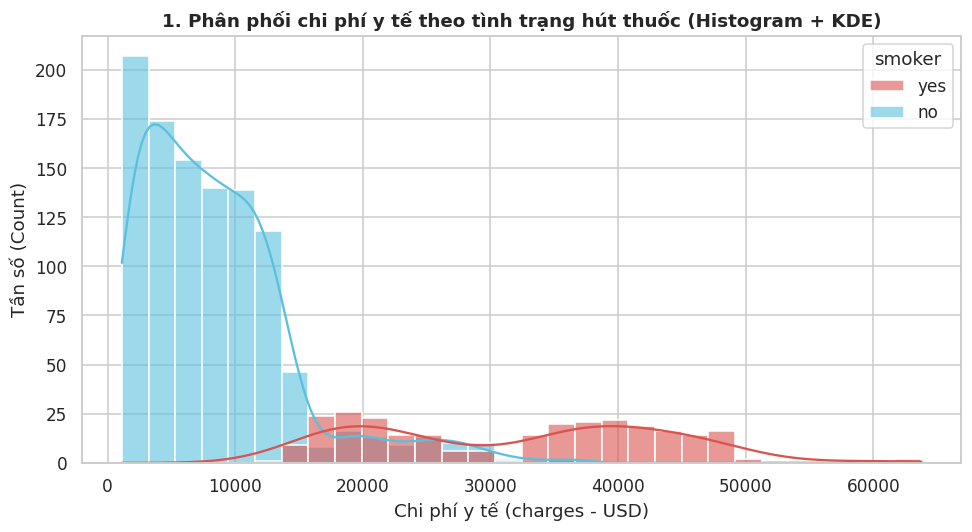

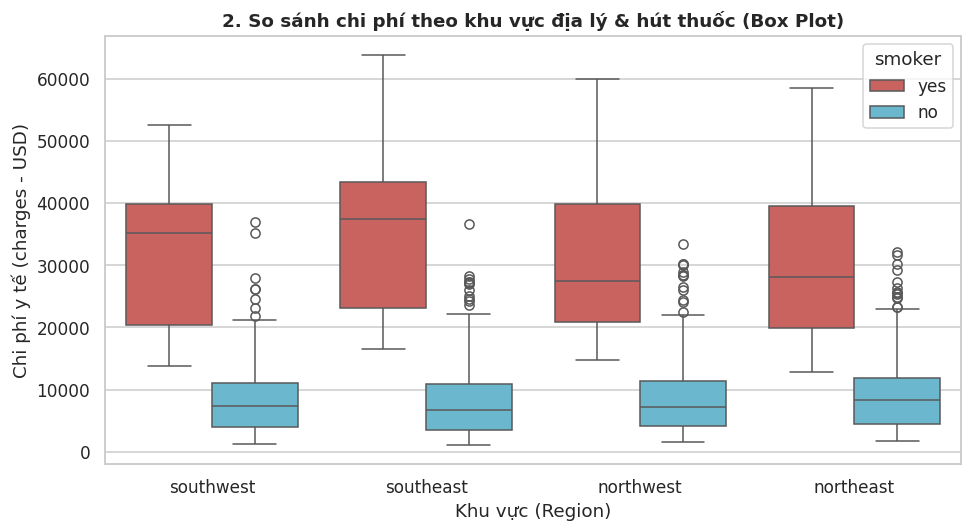

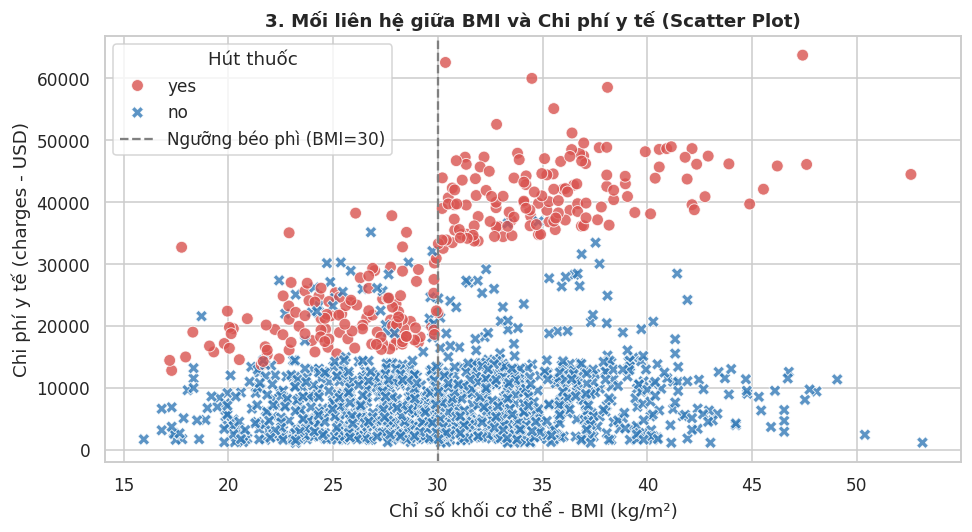

Đã lưu thành công 3 biểu đồ riêng biệt vào thư mục 'charts/'!


In [140]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu sạch
df = pd.read_csv('data/clean_data.csv')

# Cấu hình thẩm mỹ
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# ==============================================================================
# Biểu đồ 1: Histogram + KDE
# ==============================================================================
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='charges', hue='smoker', kde=True, bins=30, 
             palette={'yes': '#d9534f', 'no': '#5bc0de'}, alpha=0.6)
plt.title('1. Phân phối chi phí y tế theo tình trạng hút thuốc (Histogram + KDE)', fontsize=12, fontweight='bold')
plt.xlabel('Chi phí y tế (charges - USD)')
plt.ylabel('Tần số (Count)')
plt.tight_layout()
plt.savefig('charts/1_distribution_charges_smoker.png', dpi=300)
plt.show()
plt.close()

# ==============================================================================
# Biểu đồ 2: Box Plot
# ==============================================================================
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='region', y='charges', hue='smoker', 
            palette={'yes': '#d9534f', 'no': '#5bc0de'})
plt.title('2. So sánh chi phí theo khu vực địa lý & hút thuốc (Box Plot)', fontsize=12, fontweight='bold')
plt.xlabel('Khu vực (Region)')
plt.ylabel('Chi phí y tế (charges - USD)')
plt.tight_layout()
plt.savefig('charts/2_boxplot_charges_region_smoker.png', dpi=300)
plt.show()
plt.close()

# ==============================================================================
# Biểu đồ 3: Scatter Plot
# ==============================================================================
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', style='smoker', 
                palette={'yes': '#d9534f', 'no': '#337ab7'}, alpha=0.8, s=60)
plt.axvline(30, color='gray', linestyle='--', label='Ngưỡng béo phì (BMI=30)')
plt.title('3. Mối liên hệ giữa BMI và Chi phí y tế (Scatter Plot)', fontsize=12, fontweight='bold')
plt.xlabel('Chỉ số khối cơ thể - BMI (kg/m²)')
plt.ylabel('Chi phí y tế (charges - USD)')
plt.legend(title='Hút thuốc')
plt.tight_layout()
plt.savefig('charts/3_scatterplot_bmi_charges.png', dpi=300)
plt.show()
plt.close()

# ==============================================================================
print("Đã lưu thành công 3 biểu đồ riêng biệt vào thư mục 'charts/'!")

## 3. XỬ LÝ NGOẠI LAI
- **Phương pháp xác định:**
  1. **Quy tắc hàng rào khoảng tứ phân vị (IQR rule):** $[Q_1 - 1.5 \times IQR, Q_3 + 1.5 \times IQR]$ (thích hợp với biến lệch và không phụ thuộc giả định phân phối chuẩn).
  2. **Quy tắc điểm chuẩn hóa Z-score:** Điểm có $\vert{}Z\vert{} > 3$ (áp dụng cho biến xấp xỉ chuẩn như `bmi`).

In [141]:
# Viết hàm phát hiện outliers theo IQR
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lb = q1 - 1.5 * iqr
    ub = q3 + 1.5 * iqr
    outliers = series[(series < lb) | (series > ub)]
    return len(outliers), lb, ub

# Viết hàm phát hiện outliers theo Z-score (|Z| > 3)
def detect_outliers_zscore(series, threshold=3):
    z_scores = np.abs(stats.zscore(series))
    outliers = series[z_scores > threshold]
    return len(outliers)

def z_suitability(skew_val, is_discrete=False):
    if is_discrete:
        return "Không khuyến nghị (Biến đếm rời rạc, giá trị thực tế)"
    if abs(skew_val) < 0.5:
        return "Phù hợp (Phân phối xấp xỉ đối xứng / chuẩn)"
    elif abs(skew_val) < 1.0:
        return "Tương đối phù hợp (Lệch vừa)"
    else:
        return "Kém tin cậy (Lệch mạnh, che lấp ngoại lai)"

# 2. Khởi tạo danh sách và tổng hợp bảng so sánh
outlier_comparison = []

for col in num_cols:
    n_iqr, lb, ub = detect_outliers_iqr(df[col])
    n_z = detect_outliers_zscore(df[col], threshold=3)
    skew_val = df[col].skew()

    outlier_comparison.append({
        'Biến số': col,
        'Độ xiên (Skewness)': round(skew_val, 3),
        'Ngưỡng dưới (IQR)': round(lb, 2),
        'Ngưỡng trên (IQR)': round(ub, 2),
        'Số ngoại lai (IQR)': n_iqr,
        'Số ngoại lai (|Z| > 3)': n_z,
        'Đánh giá Z-score': z_suitability(skew_val, is_discrete=(col == 'children'))
    })

comparison_df = pd.DataFrame(outlier_comparison)
display(comparison_df)

# Phân tích bản chất các ngoại lai của charges
q1_c, q3_c = df['charges'].quantile(0.25), df['charges'].quantile(0.75)
ub_c = q3_c + 1.5 * (q3_c - q1_c)
charges_outliers = df[df['charges'] > ub_c]

print(f"\n--- PHÂN TÍCH {len(charges_outliers)} NGOẠI LAI CỦA BIẾN CHARGES (> {ub_c:.2f} USD) ---")
print("Phân bổ theo tình trạng hút thuốc:")
print(charges_outliers['smoker'].value_counts())
print(f"-> Tỷ lệ người hút thuốc trong nhóm ngoại lai: {(charges_outliers['smoker'] == 'yes').sum() / len(charges_outliers) * 100:.2f}%")

,Biến số,Độ xiên (Skewness),Ngưỡng dưới (IQR),Ngưỡng trên (IQR),Số ngoại lai (IQR),Số ngoại lai (|Z| > 3),Đánh giá Z-score
0,age,0.0550,-9.0000,87.0000,0,0,Phù hợp (Phân phối xấp xỉ đối xứng / chuẩn)
1,bmi,0.2840,13.6700,47.3200,9,4,Phù hợp (Phân phối xấp xỉ đối xứng / chuẩn)
2,children,0.9370,-3.0000,5.0000,0,18,"Không khuyến nghị (Biến đếm rời rạc, giá trị t..."
3,charges,1.5150,-13120.7200,34524.7800,139,7,"Kém tin cậy (Lệch mạnh, che lấp ngoại lai)"



--- PHÂN TÍCH 139 NGOẠI LAI CỦA BIẾN CHARGES (> 34524.78 USD) ---
Phân bổ theo tình trạng hút thuốc:
smoker
yes    136
no       3
Name: count, dtype: int64
-> Tỷ lệ người hút thuốc trong nhóm ngoại lai: 97.84%


#### 1. Đánh giá tính phù hợp giữa hai phương pháp (IQR vs Z-score)
* **Phương pháp Z-score ($\vert{}Z\vert{} > 3$):** 
  * Hoạt động tốt trên hai biến `age` (0 ngoại lai) và `bmi` (4 ngoại lai) do dữ liệu có phân phối đối xứng tiệm cận chuẩn ($\text{Skewness} \approx 0.055$ và $0.284$).
  * **Kém tin cậy trên biến `charges`:** Biến chi phí có độ lệch phải rất lớn ($\text{Skewness} = 1.515$), khiến các giá trị viện phí cực đại kéo độ lệch chuẩn $\sigma$ tăng vọt lên mức xấp xỉ $12.110$ USD. Hiện tượng này làm giãn ngưỡng trên của Z-score lên đến gần $50.000$ USD, dẫn đến **hiệu ứng che lấp ngoại lai (masking effect)** và chỉ phát hiện được 7 điểm.
  * **Không phù hợp trên biến `children`:** Vì đây là biến đếm rời rạc (từ 0 đến 5 con), Z-score gán cờ cho 18 trường hợp có 5 con là ngoại lai, dù đây là số liệu nhân khẩu học hoàn toàn hợp lệ.
* **Phương pháp IQR (Hàng rào tứ phân vị):** 
  * Mang tính **phi tham số (non-parametric)**, không bị ảnh hưởng bởi hình dạng phân phối hay các giá trị cực trị.
  * Phát hiện chính xác **9 điểm ngoại lai** ở biến `bmi` ($> 47.32\text{ kg/m}^2$) và **139 điểm ngoại lai** ở biến `charges` ($> 34.524,78$ USD), phản ánh trung thực mức độ phân tán của dữ liệu. Do đó, **IQR là phương pháp được chọn làm chuẩn nhận diện cho toàn bộ phân tích**.

### Đề xuất phương pháp xử lý ngoại lai:
1. **Đối với `bmi` (9 ngoại lai theo IQR):**
   - Giá trị BMI cao nhất là $53.13 \ kg/m^2$, hoàn toàn hợp lý về mặt sinh học lâm sàng (bệnh nhân béo phì độ III). Không phải lỗi nhập liệu. Do đó **giữ nguyên dữ liệu**.
2. **Đối với `charges` (139 ngoại lai theo IQR):**
   - Có đến **97.8% (136/139 ca)** ngoại lai thuộc nhóm có hút thuốc (`smoker = yes`). Đây là rủi ro y tế và chi phí điều trị thực tế, không phải nhiễu dữ liệu.
   - **Tuyệt đối không xóa bỏ (dropping)** hay **cắt nén phân vị chủ quan (Winsorization 99%)** vì sẽ làm sai lệch bản chất phân phối chi phí bảo hiểm.
   - **Đề xuất xử lý tối ưu:** Giữ nguyên dữ liệu trong `clean_data.csv` để làm thống kê và kiểm định; áp dụng phép biến đổi logarit $\ln(\text{charges})$ khi xây dựng mô hình Hồi quy tuyến tính đa biến ở Phần 5.

In [142]:
# ==============================================================================
# XỬ LÝ NGOẠI LAI VÀ CẬP NHẬT VÀO CLEAN_DATA.CSV
# ==============================================================================

# 1. Áp dụng phép biến đổi Log-transform để xử lý độ lệch và ngoại lai của charges
df['log_charges'] = np.log(df['charges'])

# 2. Cập nhật và lưu lại file clean_data.csv với cột dữ liệu mới
output_path = 'data/clean_data.csv'
df.to_csv(output_path, index=False)

print(f"-> ĐÃ CẬP NHẬT FILE SẠCH THÀNH CÔNG: {output_path}")
print(f"* Số lượng dòng (bảo toàn nguyên vẹn): {df.shape[0]}")
print(f"* Số lượng cột (đã thêm 'log_charges'): {df.shape[1]}")
display(df.head())

-> ĐÃ CẬP NHẬT FILE SẠCH THÀNH CÔNG: data/clean_data.csv
* Số lượng dòng (bảo toàn nguyên vẹn): 1337
* Số lượng cột (đã thêm 'log_charges'): 8


,age,sex,bmi,children,smoker,region,charges,log_charges
0,19,female,27.9000,0,yes,southwest,16884.9240,9.7342
1,18,male,33.7700,1,no,southeast,1725.5523,7.4533
2,28,male,33.0000,3,no,southeast,4449.4620,8.4005
3,33,male,22.7050,0,no,northwest,21984.4706,9.9981
4,32,male,28.8800,0,no,northwest,3866.8552,8.2602


### 4. Nhận xét tổng quan về tập dữ liệu

Dựa trên kết quả khám phá dữ liệu (EDA), kiểm tra tính toàn vẹn và trực quan hóa, rút ra 5 đặc điểm nổi bật sau:

* **Chất lượng dữ liệu đạt chuẩn cao:** Bộ dữ liệu gồm **1.337 quan sát** và **7 biến số** sau khi loại bỏ 1 dòng trùng lặp. Dữ liệu không có giá trị khuyết thiếu (0 missing value), 100% biến phân loại và biến số đều nằm đúng miền giá trị logic kỳ vọng.
* **Cơ cấu nhân khẩu học phân bổ đồng đều:** 
  * Giới tính cân bằng tối ưu giữa Nam (50.5%) và Nữ (49.5%).
  * Địa bàn cư trú chia đều cho 4 khu vực (mỗi vùng xấp xỉ 24% – 27%).
  * Độ tuổi trải rộng từ 18 đến 64 tuổi (trung bình 39.2 tuổi), đại diện tốt cho độ tuổi lao động tham gia bảo hiểm.
* **Biến thể trạng (BMI) tiệm cận phân phối chuẩn:** Chỉ số BMI có phân phối hình chuông đối xứng quanh giá trị trung bình **30.66 kg/m²** (ngưỡng thừa cân/tiền béo phì theo chuẩn WHO). Có 9 trường hợp ngoại lai phía trên ($BMI > 47.32$) nhưng hoàn toàn phù hợp với thực tế y khoa.
* **Biến mục tiêu (charges) lệch phải mạnh:** Chi phí y tế có độ xiên dương lớn ($\text{Skewness} = 1.515$), giá trị trung bình ($13.279$ USD) chênh lệch đáng kể so với trung vị ($9.386$ USD). Toàn bộ 139 điểm ngoại lai thống kê ($> 34.525$ USD) đều là chi phí phát sinh thực tế với phân phối đuôi dài (fat-tail).
* **Hành vi hút thuốc là yếu tố chi phối rủi ro hàng đầu:**
  * Nhóm hút thuốc chỉ chiếm **20.5%** tổng mẫu nhưng chiếm đến **97.8% (136/139)** số ca viện phí ngoại lai.
  * Chi phí y tế trung bình của người hút thuốc vọt lên mức **~32.050 USD** (cao gấp 3.8 lần nhóm không hút thuốc, vốn chỉ ~8.441 USD).
  * Xuất hiện **hiệu ứng tương tác rõ rệt giữa BMI và hút thuốc:** Người hút thuốc kèm thể trạng béo phì ($BMI \ge 30$) có chi phí điều trị tăng vọt lên phân khúc cao nhất ($> 35.000$ USD).

---
---
# PHẦN 2: PHÂN TÍCH PHÂN PHỐI XÁC SUẤT
---


# 2. Phân tích phân phối xác suất

Mục tiêu của phần này là kiểm tra xem hai biến quan trọng trong tập dữ liệu (`bmi` và `charges`) có tuân theo phân phối xác suất nào không (ví dụ: phân phối chuẩn).
Chúng ta sẽ sử dụng các biểu đồ như Histogram, KDE và Q-Q plot, cùng với các kiểm định thống kê để đưa ra kết luận.

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Thiết lập style cho biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Đọc dữ liệu đã được làm sạch
df = pd.read_csv('data/clean_data.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges,log_charges
0,19,female,27.9000,0,yes,southwest,16884.9240,9.7342
1,18,male,33.7700,1,no,southeast,1725.5523,7.4533
2,28,male,33.0000,3,no,southeast,4449.4620,8.4005
3,33,male,22.7050,0,no,northwest,21984.4706,9.9981
4,32,male,28.8800,0,no,northwest,3866.8552,8.2602


## 2.1. Phân phối của biến `bmi` (Chỉ số khối cơ thể)

Biến `bmi` là một biến liên tục đo lường chỉ số khối cơ thể. Chúng ta sẽ kiểm tra xem `bmi` có tuân theo phân phối chuẩn (Normal Distribution) hay không.

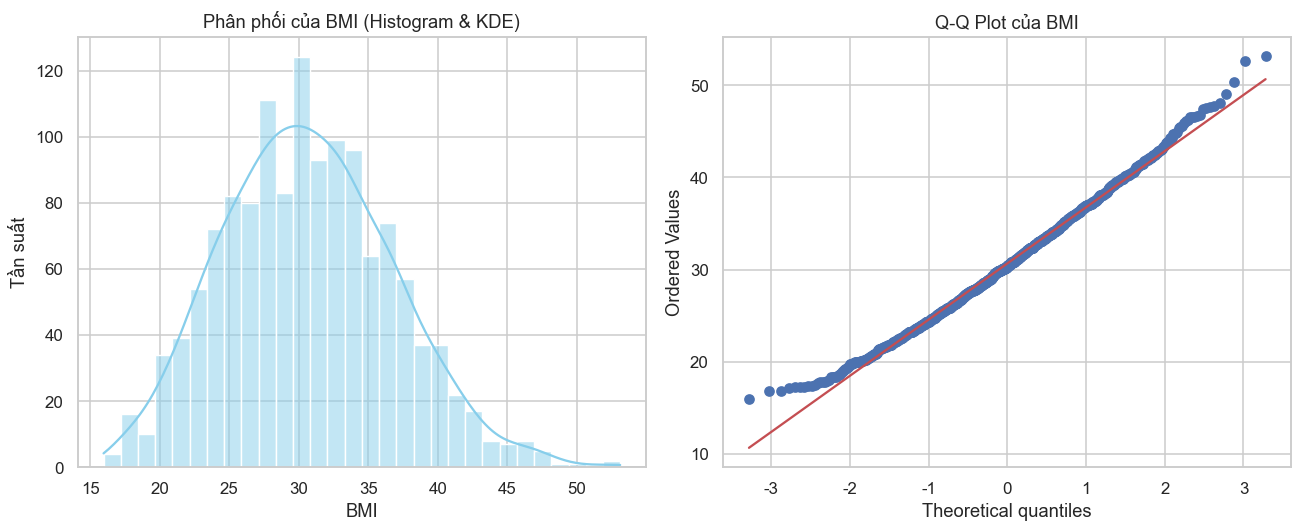

Kiểm định Shapiro-Wilk cho BMI:
Statistics=0.994, p=0.000
Nhận xét: Bác bỏ giả thuyết H0 (Dữ liệu không hoàn toàn tuân theo phân phối chuẩn).


In [144]:
# Vẽ biểu đồ Histogram và KDE cho bmi
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['bmi'], kde=True, color='skyblue', bins=30)
plt.title('Phân phối của BMI (Histogram & KDE)')
plt.xlabel('BMI')
plt.ylabel('Tần suất')

# Vẽ biểu đồ Q-Q plot cho bmi
plt.subplot(1, 2, 2)
stats.probplot(df['bmi'], dist="norm", plot=plt)
plt.title('Q-Q Plot của BMI')

plt.tight_layout()
import os
plt.savefig('charts/bmi_distribution.png', bbox_inches='tight')
plt.show()

# Kiểm định Shapiro-Wilk cho biến bmi (chỉ lấy mẫu ngẫu nhiên do data lớn nếu cần, nhưng với data này ~1300 dòng thì có thể chạy trực tiếp)
stat, p = stats.shapiro(df['bmi'])
print('Kiểm định Shapiro-Wilk cho BMI:')
print('Statistics=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Nhận xét: Không có bằng chứng để bác bỏ giả thuyết H0 (Dữ liệu có phân phối chuẩn).')
else:
    print('Nhận xét: Bác bỏ giả thuyết H0 (Dữ liệu không hoàn toàn tuân theo phân phối chuẩn).')

**Nhận xét:**
- Dựa trên biểu đồ, phân phối của `bmi` có dạng hình chuông gần đối xứng, đỉnh quanh 30, Q-Q bám khá sát đường chéo, hai đuôi lệch nhẹ (đuôi phải dài hơn). Về mặt thực tiễn, phân phối này xấp xỉ chuẩn.
- Skewness = 0.28, Kurtosis (kurtosis dư - baseline là 0 cho phân phối chuẩn) = -0.05.
- Kiểm định Shapiro-Wilk cho p-value = 2.575e-05 < 0.05. Do cỡ mẫu n lớn (≈1300), kiểm định Shapiro-Wilk rất nhạy cảm với những sai lệch nhỏ nên bác bỏ giả thuyết phân phối chuẩn. Tuy nhiên, qua quan sát thực tế (histogram, Q-Q plot), ta vẫn có thể coi `bmi` tuân theo phân phối xấp xỉ chuẩn cho mục đích phân tích.
- Lưu ý: Đề bài có đề cập đến phân phối Poisson, tuy nhiên Poisson dành cho biến đếm rời rạc, còn `bmi` và `charges` là các biến liên tục nên ta không áp dụng phân phối Poisson.

## 2.2. Phân phối của biến `charges` (Chi phí y tế)

Biến `charges` là chi phí y tế được lập hóa đơn cho bệnh nhân. Chi phí thường bị lệch phải do có một số bệnh nhân có chi phí điều trị rất cao.

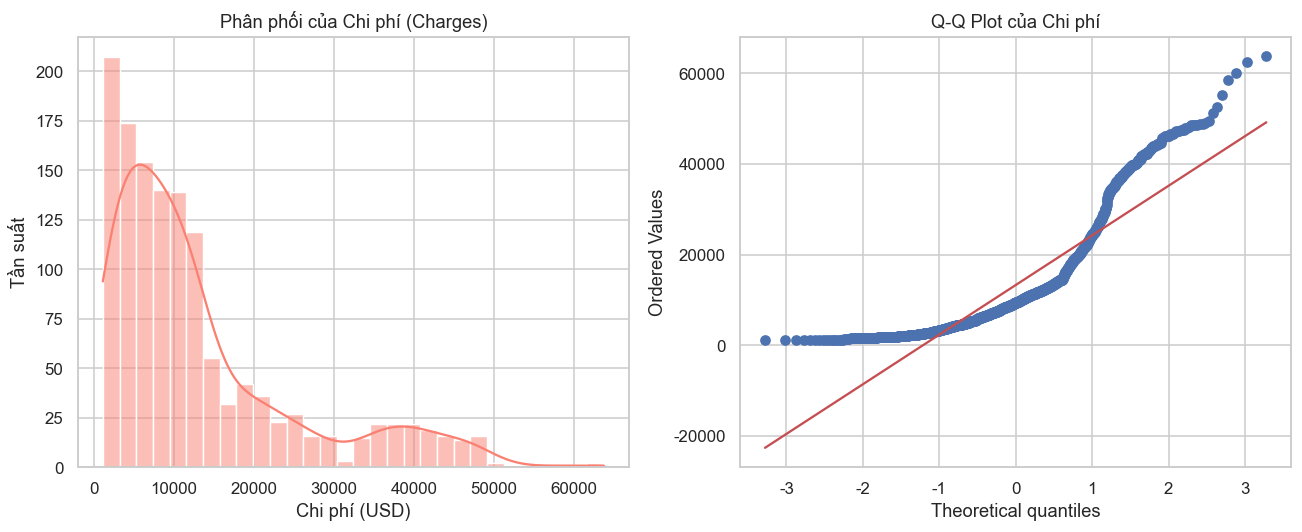

In [145]:
# Vẽ biểu đồ Histogram và KDE cho charges
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['charges'], kde=True, color='salmon', bins=30)
plt.title('Phân phối của Chi phí (Charges)')
plt.xlabel('Chi phí (USD)')
plt.ylabel('Tần suất')

# Vẽ biểu đồ Q-Q plot cho charges
plt.subplot(1, 2, 2)
stats.probplot(df['charges'], dist="norm", plot=plt)
plt.title('Q-Q Plot của Chi phí')

plt.tight_layout()
plt.savefig('charts/charges_distribution.png', bbox_inches='tight')
plt.show()

**Nhận xét:**
- Biến `charges` lệch phải rất mạnh (Skewness = 1.52, Kurtosis dư = 1.60). Kiểm định Shapiro-Wilk của `charges` cũng bác bỏ phân phối chuẩn.
- Đồ thị Q-Q plot cong hẳn khỏi đường chéo, cho thấy phân phối không chuẩn.
- Nhìn biểu đồ ban đầu có vẻ giống Exponential hoặc Log-Normal. Sau khi kiểm định KS (Kolmogorov-Smirnov) và so sánh Statistic D (D nhỏ hơn nghĩa là phân phối khớp hơn; ta dùng D để đánh giá mức độ phù hợp thay vì p-value vì p-value dễ bị thổi phồng khi tham số được ước lượng từ chính dữ liệu) giữa Normal, Exponential (đã ước lượng loc/scale) và Log-Normal, ta thấy Log-Normal và Exponential tốt hơn so với chuẩn, nhưng không hoàn hảo.
- Vẽ đồ thị chồng lên (xem ở dưới) cho thấy biến `charges` là hỗn hợp của các nhóm (hút thuốc và không hút thuốc) nên không khớp trọn vẹn với phân phối đơn nào.

### 2.2.1. Chuẩn hóa biến `charges` bằng Log Transformation

Vì `charges` bị lệch phải mạnh, trong phân tích thống kê và hồi quy, người ta thường dùng phép biến đổi Logarit tự nhiên (log transformation) để kéo phân phối về gần chuẩn hơn. 
(Trong tập dữ liệu đã có sẵn cột `log_charges`, ta sẽ kiểm tra phân phối của cột này)

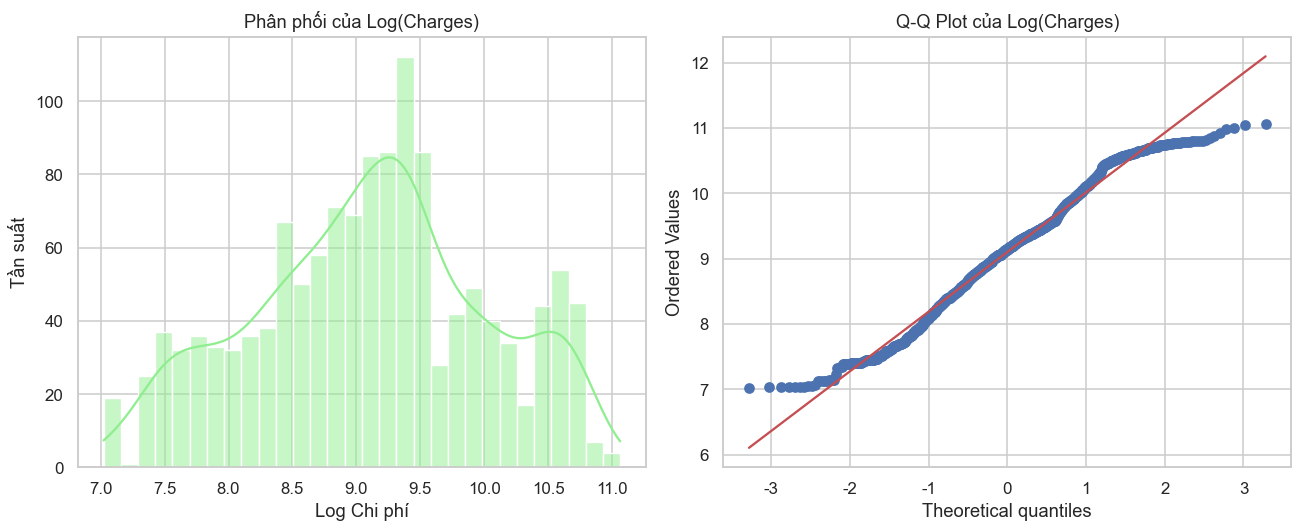

In [146]:
# Vẽ biểu đồ Histogram và KDE cho log_charges
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['log_charges'], kde=True, color='lightgreen', bins=30)
plt.title('Phân phối của Log(Charges)')
plt.xlabel('Log Chi phí')
plt.ylabel('Tần suất')

# Vẽ biểu đồ Q-Q plot cho log_charges
plt.subplot(1, 2, 2)
stats.probplot(df['log_charges'], dist="norm", plot=plt)
plt.title('Q-Q Plot của Log(Charges)')

plt.tight_layout()
plt.savefig('charts/log_charges_distribution.png', bbox_inches='tight')
plt.show()

**Nhận xét:**
- Việc log-transform đã giúp giảm độ lệch phải (Skewness giảm từ 1.52 xuống -0.09, Kurtosis giảm từ 1.60 xuống -0.63). Đồ thị histogram cho thấy phân phối đối xứng hơn rất nhiều.
- Tuy nhiên, biến `log_charges` vẫn không hoàn toàn chuẩn (Q-Q plot có dạng chữ S, đuôi hai bên phẳng, histogram có biểu hiện phân phối bimodal - nhiều đỉnh). Do `log(charges)` không chuẩn, nên `charges` không thực sự là phân phối Log-Normal chuẩn.

--- Skewness & Kurtosis (excess) ---
BMI - Skewness: 0.28, Kurtosis: -0.05
Charges - Skewness: 1.52, Kurtosis: 1.60
Log Charges - Skewness: -0.09, Kurtosis: -0.63

--- Shapiro-Wilk Test ---
BMI -> Statistic: 0.9939, p-value: 2.575e-05
Charges -> Statistic: 0.8148, p-value: 1.196e-36
Log Charges -> Statistic: 0.9833, p-value: 2.573e-11

--- Kolmogorov-Smirnov Test for Charges (Dùng Statistic D để so sánh) ---
KS-Test vs Normal      -> Statistic D: 0.1885
KS-Test vs Log-Normal  -> Statistic D: 0.0367
KS-Test vs Exponential -> Statistic D: 0.0611


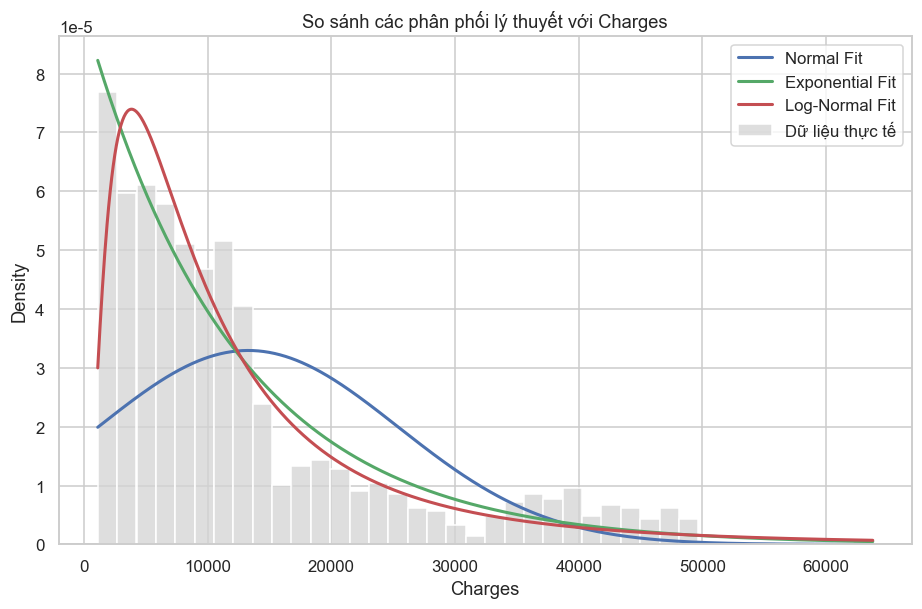

In [147]:

import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('--- Skewness & Kurtosis (excess) ---')
print(f"BMI - Skewness: {df['bmi'].skew():.2f}, Kurtosis: {df['bmi'].kurt():.2f}")
print(f"Charges - Skewness: {df['charges'].skew():.2f}, Kurtosis: {df['charges'].kurt():.2f}")
print(f"Log Charges - Skewness: {df['log_charges'].skew():.2f}, Kurtosis: {df['log_charges'].kurt():.2f}")

print('\n--- Shapiro-Wilk Test ---')
stat_b, p_b = stats.shapiro(df['bmi'])
print(f"BMI -> Statistic: {stat_b:.4f}, p-value: {p_b:.4g}")
stat_c, p_c = stats.shapiro(df['charges'])
print(f"Charges -> Statistic: {stat_c:.4f}, p-value: {p_c:.4g}")
stat_lc, p_lc = stats.shapiro(df['log_charges'])
print(f"Log Charges -> Statistic: {stat_lc:.4f}, p-value: {p_lc:.4g}")

print('\n--- Kolmogorov-Smirnov Test for Charges (Dùng Statistic D để so sánh) ---')
# KS test for Normal
norm_loc, norm_scale = stats.norm.fit(df['charges'])
stat_ks_norm, _ = stats.kstest(df['charges'], 'norm', args=(norm_loc, norm_scale))
print(f"KS-Test vs Normal      -> Statistic D: {stat_ks_norm:.4f}")

# KS test for log-normal
log_shape = np.std(df['log_charges'])
log_loc = 0
log_scale = np.exp(np.mean(df['log_charges']))
stat_ks_log, _ = stats.kstest(df['charges'], 'lognorm', args=(log_shape, log_loc, log_scale))
print(f"KS-Test vs Log-Normal  -> Statistic D: {stat_ks_log:.4f}")

# KS test for exponential
exp_loc, exp_scale = stats.expon.fit(df['charges'])
stat_ks_exp, _ = stats.kstest(df['charges'], 'expon', args=(exp_loc, exp_scale))
print(f"KS-Test vs Exponential -> Statistic D: {stat_ks_exp:.4f}")

# Vẽ biểu đồ chồng lên histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['charges'], stat='density', bins=40, color='lightgray', label='Dữ liệu thực tế')
x = np.linspace(df['charges'].min(), df['charges'].max(), 1000)
plt.plot(x, stats.norm.pdf(x, norm_loc, norm_scale), 'b-', lw=2, label='Normal Fit')
plt.plot(x, stats.expon.pdf(x, exp_loc, exp_scale), 'g-', lw=2, label='Exponential Fit')
plt.plot(x, stats.lognorm.pdf(x, log_shape, log_loc, log_scale), 'r-', lw=2, label='Log-Normal Fit')
plt.title('So sánh các phân phối lý thuyết với Charges')
plt.xlabel('Charges')
plt.ylabel('Density')
plt.legend()
plt.savefig('charts/charges_theoretical_fit.png', bbox_inches='tight')
plt.show()


---
---
# PHẦN 3: KIỂM ĐỊNH GIẢ THUYẾT
---


# Phần 3: Kiểm định giả thuyết thống kê
---

**Nội dung notebook**

| Phần | Nội dung |
|---|---|
| **A** | Cơ sở lý thuyết: nền tảng kiểm định giả thuyết, T-test, Chi-square, ANOVA |
| **B** | Chuẩn bị dữ liệu (dùng file `clean_data.csv` đã làm sạch ở Phần 1) |
| **C** | Câu hỏi nghiên cứu 1: Hút thuốc có làm chi phí y tế khác biệt không? (**T-test**) |
| **D** | Câu hỏi nghiên cứu 2: Nhóm thể trạng BMI có chi phí y tế khác nhau không? (**ANOVA**) |
| **E** | Tổng kết |

---
# PHẦN A. CƠ SỞ LÝ THUYẾT

## A.0 Nền tảng chung của kiểm định giả thuyết

Ở các phần trước, chúng ta **mô tả** dữ liệu (thống kê mô tả, biểu đồ). Kiểm định giả thuyết trả lời câu hỏi tiếp theo: *khác biệt hoặc mối liên hệ quan sát được trên mẫu là có thật ở tổng thể, hay chỉ là do dao động ngẫu nhiên khi lấy mẫu?*

**Các khái niệm cốt lõi**

- **Giả thuyết không (H0):** khẳng định "không có khác biệt / không có liên hệ". Đây là giả thuyết được đem ra kiểm tra.
- **Giả thuyết đối (H1):** khẳng định ngược lại với H0 (có khác biệt / có liên hệ).
- **Mức ý nghĩa (α):** xác suất tối đa chấp nhận mắc **sai lầm loại I** (bác bỏ H0 trong khi H0 thật sự đúng). Thông thường chọn **α = 0,05**.
- **Thống kê kiểm định:** một con số tính từ mẫu (t, χ², F, ...) đo mức độ dữ liệu lệch khỏi những gì H0 dự đoán.
- **P-value (giá trị p):** xác suất thu được kết quả **cực đoan bằng hoặc hơn** kết quả quan sát, **với điều kiện H0 đúng**.

**Quy tắc quyết định**

| Kết quả | Quyết định | Diễn giải |
|---|---|---|
| p-value < α | Bác bỏ H0 | Có bằng chứng thống kê cho thấy khác biệt / liên hệ là có thật |
| p-value ≥ α | Không bác bỏ H0 | Chưa đủ bằng chứng (không có nghĩa là H0 chắc chắn đúng) |

**Những điều cần nhớ khi đọc p-value**

1. P-value **không** phải xác suất H0 đúng.
2. P-value nhỏ chỉ cho biết khác biệt **có thật**, **không** cho biết khác biệt **lớn hay nhỏ**. Vì vậy cần báo cáo thêm **độ lớn hiệu ứng** (effect size) như Cohen's d, Cramér's V, η².
3. Kiểm định chỉ phát hiện **mối liên hệ**, không chứng minh **quan hệ nhân quả**.

**Quy trình 5 bước thực hiện kiểm định:** (1) đặt giả thuyết H0/H1 → (2) chọn α → (3) kiểm tra điều kiện áp dụng → (4) tính thống kê kiểm định và p-value → (5) kết luận trong ngữ cảnh bài toán.

**Chọn phép kiểm định phù hợp**

| Biến phụ thuộc | Biến phân nhóm / biến còn lại | Số nhóm | Phép kiểm định |
|---|---|---|---|
| Định lượng | Phân loại | 2 | **T-test** |
| Định lượng | Phân loại | ≥ 3 | **ANOVA** |
| Phân loại | Phân loại | bất kỳ | **Chi-square** |

## A.1. T-test (Kiểm định T)

**Mục đích.** So sánh **giá trị trung bình của hai nhóm** để xác định chênh lệch giữa hai trung bình là có ý nghĩa thống kê hay chỉ do ngẫu nhiên.

**Các dạng T-test**

| Dạng | Tình huống sử dụng |
|---|---|
| *One-sample t-test* | So sánh trung bình một nhóm với một giá trị cho trước |
| *Independent samples t-test* | So sánh trung bình hai nhóm **độc lập** (ví dụ: hút thuốc và không hút thuốc) |
| *Paired t-test* | So sánh hai lần đo trên **cùng một đối tượng** (ví dụ: trước và sau điều trị) |

**Giả thuyết (hai phía)**

$$H_0:\ \mu_1 = \mu_2 \qquad\qquad H_1:\ \mu_1 \neq \mu_2$$

**Thống kê kiểm định.** Với hai nhóm độc lập, phương sai không nhất thiết bằng nhau, dùng **Welch's t-test**:

$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\dfrac{s_1^2}{n_1} + \dfrac{s_2^2}{n_2}}}$$

với $\bar{x}_i$ là trung bình mẫu, $s_i^2$ là phương sai mẫu, $n_i$ là cỡ mẫu của nhóm $i$. Bậc tự do tính theo công thức Welch–Satterthwaite:

$$df = \frac{\left(\dfrac{s_1^2}{n_1} + \dfrac{s_2^2}{n_2}\right)^2}{\dfrac{(s_1^2/n_1)^2}{n_1-1} + \dfrac{(s_2^2/n_2)^2}{n_2-1}}$$

**Điều kiện áp dụng**

1. Biến phụ thuộc là biến **định lượng**; biến phân nhóm có **đúng 2 nhóm**.
2. Các quan sát **độc lập** với nhau.
3. Dữ liệu mỗi nhóm xấp xỉ **phân phối chuẩn**. Khi cỡ mẫu lớn (n > 30 mỗi nhóm), *định lý giới hạn trung tâm* cho phép nới lỏng điều kiện này.
4. Phương sai hai nhóm bằng nhau (kiểm tra bằng **Levene**). Nếu không bằng nhau, dùng **Welch's t-test** (không yêu cầu điều kiện này).

*Phương án thay thế khi vi phạm điều kiện:* kiểm định phi tham số **Mann–Whitney U**.

**Độ lớn hiệu ứng: Cohen's d**

$$d = \frac{\bar{x}_1 - \bar{x}_2}{s_p}, \qquad s_p = \sqrt{\frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}}$$

Quy ước: |d| ≈ 0,2 (nhỏ); ≈ 0,5 (trung bình); ≥ 0,8 (lớn).

**Cách đọc kết quả.** Nếu p < α thì bác bỏ H0: trung bình hai nhóm khác nhau có ý nghĩa thống kê.

## A.2. Chi-square (Kiểm định Chi bình phương về tính độc lập)

**Mục đích.** Kiểm tra có **mối liên hệ giữa hai biến phân loại** hay không, bằng cách so sánh **tần số quan sát** với **tần số kỳ vọng** nếu hai biến độc lập.

**Giả thuyết**

- H0: hai biến **độc lập** (không có mối liên hệ).
- H1: hai biến **có liên hệ** với nhau.

**Thống kê kiểm định**

$$\chi^2 = \sum \frac{(O - E)^2}{E}, \qquad E_{ij} = \frac{(\text{tổng hàng } i)\times(\text{tổng cột } j)}{N}$$

với O là tần số quan sát, E là tần số kỳ vọng. Bậc tự do: $df = (r-1)(c-1)$, trong đó r là số hàng, c là số cột của bảng chéo (contingency table).

**Điều kiện áp dụng**

1. Cả hai biến đều là biến **phân loại**.
2. Các quan sát **độc lập**, mỗi quan sát chỉ thuộc đúng một ô.
3. **Tần số kỳ vọng ở mỗi ô ≥ 5** (nếu không thỏa, dùng **Fisher's exact test** cho bảng 2×2).

**Độ lớn hiệu ứng: Cramér's V**

$$V = \sqrt{\frac{\chi^2}{N\cdot \min(r-1,\ c-1)}}$$

V nằm trong khoảng 0 đến 1. Với bảng 2×2 (df = 1): V ≈ 0,1 (nhỏ); ≈ 0,3 (trung bình); ≥ 0,5 (lớn).

**Cách đọc kết quả.** Nếu p < α thì bác bỏ H0: hai biến có liên hệ. Chi-square **chỉ cho biết có liên hệ hay không**, không cho biết chiều hướng nhân quả; muốn biết chiều hướng cần xem thêm bảng tỷ lệ phần trăm.

## A.3. ANOVA (Phân tích phương sai một yếu tố – One-way ANOVA)

**Mục đích.** So sánh **trung bình của 3 nhóm trở lên** cùng một lúc.

**Tại sao không chạy nhiều lần T-test?** Với k nhóm cần $\binom{k}{2}$ phép so sánh cặp. Mỗi phép có 5% nguy cơ sai lầm loại I, nên xác suất mắc ít nhất một sai lầm tăng nhanh. Ví dụ với 4 nhóm (6 cặp): $1-(1-0{,}05)^6 \approx 26\%$. ANOVA kiểm soát rủi ro này bằng **một** phép kiểm định tổng thể.

**Nguyên lý.** ANOVA so sánh hai nguồn biến thiên:

- **Giữa các nhóm** (between-group): do trung bình các nhóm khác nhau.
- **Trong nội bộ nhóm** (within-group): do sai khác ngẫu nhiên giữa các cá thể.

Nếu biến thiên giữa các nhóm lớn hơn nhiều so với trong nhóm, ta có cơ sở cho rằng trung bình các nhóm không đồng nhất.

**Giả thuyết**

$$H_0:\ \mu_1 = \mu_2 = \dots = \mu_k \qquad\qquad H_1:\ \text{có ít nhất một nhóm có trung bình khác các nhóm còn lại}$$

**Thống kê kiểm định**

$$F = \frac{MS_B}{MS_W} = \frac{SS_B/(k-1)}{SS_W/(N-k)}$$

trong đó $SS_B$ là tổng bình phương giữa các nhóm, $SS_W$ là tổng bình phương trong nhóm, k là số nhóm, N là tổng số quan sát. F càng lớn thì bằng chứng chống lại H0 càng mạnh.

**Điều kiện áp dụng**

1. Biến phụ thuộc là biến **định lượng**; biến phân nhóm có **từ 3 nhóm trở lên**.
2. Các quan sát **độc lập**.
3. Dữ liệu mỗi nhóm xấp xỉ **phân phối chuẩn** (nới lỏng khi cỡ mẫu lớn).
4. **Phương sai các nhóm đồng nhất** (kiểm tra bằng Levene).

*Phương án thay thế khi vi phạm:* **Welch's ANOVA** (không cần phương sai bằng nhau) hoặc **Kruskal–Wallis** (phi tham số).

**Độ lớn hiệu ứng: Eta bình phương**

$$\eta^2 = \frac{SS_B}{SS_T}$$

cho biết tỷ lệ biến thiên của biến phụ thuộc được giải thích bởi biến phân nhóm. Quy ước: ≈ 0,01 (nhỏ); ≈ 0,06 (trung bình); ≥ 0,14 (lớn).

**Kiểm định hậu nghiệm (post-hoc).** ANOVA chỉ cho biết *có ít nhất một nhóm khác biệt*, **không** chỉ ra *nhóm nào khác nhóm nào*. Khi p < α, cần chạy thêm **Tukey HSD** để so sánh từng cặp nhóm, đã hiệu chỉnh để kiểm soát sai lầm loại I.

**Cách đọc kết quả.** Nếu p < α thì bác bỏ H0, sau đó dùng Tukey HSD để xác định các cặp nhóm khác biệt.

---
# PHẦN B. CHUẨN BỊ DỮ LIỆU

Bộ dữ liệu gồm các biến: `age` (tuổi), `sex` (giới tính), `bmi` (chỉ số khối cơ thể), `children` (số con), `smoker` (có hút thuốc hay không), `region` (khu vực) và **`charges`** (chi phí y tế, đơn vị USD; biến mục tiêu).

In [148]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.options.display.float_format = "{:,.2f}".format

ALPHA = 0.05   # mức ý nghĩa dùng cho toàn bộ notebook

In [149]:
# Đọc file dữ liệu sạch (kết quả của Phần 1: đã xử lý missing values và duplicates)
df = pd.read_csv("data/clean_data.csv")

print(f"Kích thước dữ liệu: {df.shape[0]:,} dòng x {df.shape[1]} cột")
print(f"Giá trị thiếu: {df.isna().sum().sum()} | Dòng trùng lặp: {df.duplicated().sum()}")
print()
df.info()

Kích thước dữ liệu: 1,337 dòng x 8 cột
Giá trị thiếu: 0 | Dòng trùng lặp: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          1337 non-null   int64  
 1   sex          1337 non-null   object 
 2   bmi          1337 non-null   float64
 3   children     1337 non-null   int64  
 4   smoker       1337 non-null   object 
 5   region       1337 non-null   object 
 6   charges      1337 non-null   float64
 7   log_charges  1337 non-null   float64
dtypes: float64(3), int64(2), object(3)
memory usage: 83.7+ KB


In [150]:
df.head()

,age,sex,bmi,children,smoker,region,charges,log_charges
0,19,female,27.90,0,yes,southwest,"16,884.92",9.73
1,18,male,33.77,1,no,southeast,"1,725.55",7.45
2,28,male,33.00,3,no,southeast,"4,449.46",8.40
3,33,male,22.70,0,no,northwest,"21,984.47",10.00
4,32,male,28.88,0,no,northwest,"3,866.86",8.26


In [151]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,"1,337.00",39.22,14.04,18.00,27.00,39.00,51.00,64.00
bmi,"1,337.00",30.66,6.10,15.96,26.29,30.40,34.70,53.13
children,"1,337.00",1.10,1.21,0.00,0.00,1.00,2.00,5.00
charges,"1,337.00","13,279.12","12,110.36","1,121.87","4,746.34","9,386.16","16,657.72","63,770.43"
log_charges,"1,337.00",9.10,0.92,7.02,8.47,9.15,9.72,11.06


---
# PHẦN C. CÂU HỎI NGHIÊN CỨU 1: HÚT THUỐC VÀ CHI PHÍ Y TẾ (T-test)

### Câu hỏi
> **Chi phí y tế trung bình của người hút thuốc có khác biệt so với người không hút thuốc hay không?**

### Thiết kế kiểm định

| Thành phần | Nội dung |
|---|---|
| Biến phụ thuộc | `charges` (định lượng) |
| Biến phân nhóm | `smoker` (2 nhóm: `yes` / `no`) |
| Phép kiểm định | Independent samples t-test (Welch) |
| H0 | $\mu_{hút\ thuốc} = \mu_{không\ hút\ thuốc}$ |
| H1 | $\mu_{hút\ thuốc} \neq \mu_{không\ hút\ thuốc}$ |
| Mức ý nghĩa | α = 0,05 |

### Bước 1. Thống kê mô tả và trực quan hóa

In [152]:
smoker_charges     = df.loc[df["smoker"] == "yes", "charges"]
non_smoker_charges = df.loc[df["smoker"] == "no",  "charges"]

summary1 = df.groupby("smoker")["charges"].agg(["count", "mean", "median", "std", "min", "max"])
summary1.index = summary1.index.map({"no": "Không hút thuốc", "yes": "Hút thuốc"})
summary1

,count,mean,median,std,min,max
smoker,,,,,,
Không hút thuốc,1063,"8,440.66","7,345.73","5,992.97","1,121.87","36,910.61"
Hút thuốc,274,"32,050.23","34,456.35","11,541.55","12,829.46","63,770.43"


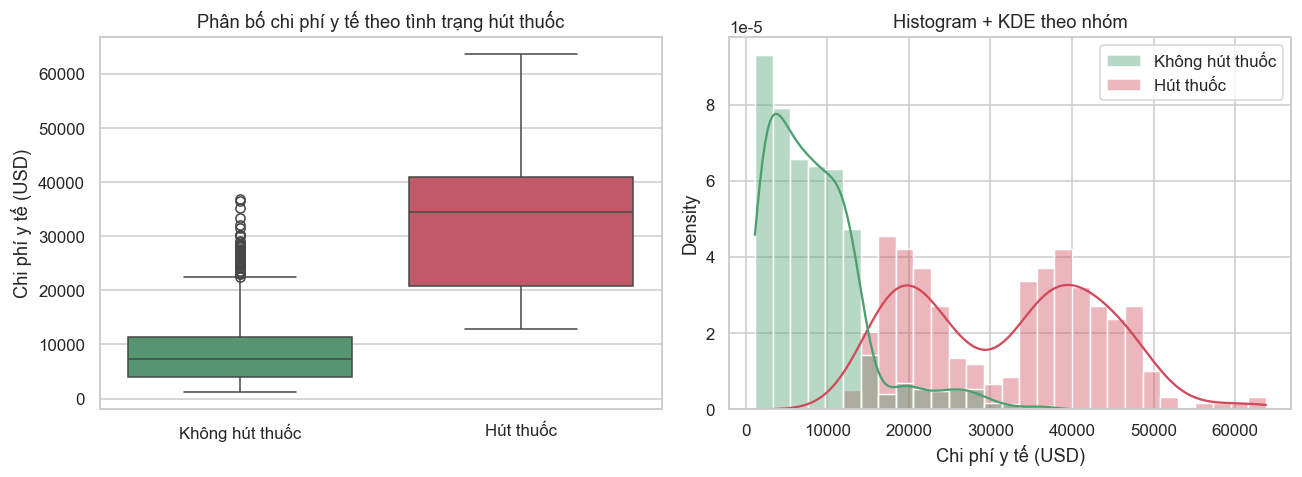

In [153]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_df = df.assign(nhom=df["smoker"].map({"no": "Không hút thuốc", "yes": "Hút thuốc"}))
order   = ["Không hút thuốc", "Hút thuốc"]
palette = {"Không hút thuốc": "#4C9F70", "Hút thuốc": "#D1495B"}

sns.boxplot(data=plot_df, x="nhom", y="charges", order=order, palette=palette, ax=axes[0])
axes[0].set_xlabel("")
axes[0].set_ylabel("Chi phí y tế (USD)")
axes[0].set_title("Phân bố chi phí y tế theo tình trạng hút thuốc")

sns.histplot(data=plot_df, x="charges", hue="nhom", hue_order=order, kde=True, stat="density",
             common_norm=False, palette=palette, alpha=0.4, ax=axes[1])
axes[1].set_xlabel("Chi phí y tế (USD)")
axes[1].set_title("Histogram + KDE theo nhóm")
axes[1].get_legend().set_title("")

plt.tight_layout()
plt.show()

### Bước 2. Kiểm tra điều kiện áp dụng

In [154]:
# (a) Phân phối chuẩn: Shapiro-Wilk (H0: dữ liệu có phân phối chuẩn)
print("Kiểm tra phân phối chuẩn (Shapiro-Wilk):")
for name, g in [("Hút thuốc", smoker_charges), ("Không hút thuốc", non_smoker_charges)]:
    w, p = stats.shapiro(g)
    print(f"  - {name:<16}: n = {len(g):>4}, W = {w:.4f}, p = {p:.2e}, độ lệch (skew) = {stats.skew(g):.2f}")

# (b) Phương sai đồng nhất: Levene (H0: phương sai hai nhóm bằng nhau)
lev_stat, lev_p = stats.levene(smoker_charges, non_smoker_charges)
print(f"\nKiểm tra phương sai đồng nhất (Levene): thống kê = {lev_stat:.2f}, p = {lev_p:.2e}")

Kiểm tra phân phối chuẩn (Shapiro-Wilk):
  - Hút thuốc       : n =  274, W = 0.9396, p = 3.62e-09, độ lệch (skew) = 0.13
  - Không hút thuốc : n = 1063, W = 0.8729, p = 1.50e-28, độ lệch (skew) = 1.54

Kiểm tra phương sai đồng nhất (Levene): thống kê = 332.47, p = 1.67e-66


**Nhận xét điều kiện:**

- **Phân phối chuẩn bị vi phạm** ở cả hai nhóm (Shapiro p rất nhỏ; nhóm không hút thuốc lệch phải rõ rệt với độ lệch ≈ 1,54). Tuy nhiên mỗi nhóm có hàng trăm quan sát (274 và 1.063), nên theo định lý giới hạn trung tâm, T-test vẫn đáng tin cậy. Để chắc chắn, ta kiểm tra lại bằng Mann–Whitney U (không đòi hỏi phân phối chuẩn).
- **Phương sai hai nhóm khác nhau rõ rệt** (Levene p rất nhỏ) → bắt buộc dùng **Welch's t-test** (`equal_var=False`) thay vì T-test thông thường.
- Các quan sát độc lập vì mỗi dòng là một cá nhân khác nhau.

### Bước 3. Chạy kiểm định

In [155]:
# --- Welch's t-test ---
t_stat, p_val = stats.ttest_ind(smoker_charges, non_smoker_charges, equal_var=False)

n1, n2 = len(smoker_charges), len(non_smoker_charges)
m1, m2 = smoker_charges.mean(), non_smoker_charges.mean()
v1, v2 = smoker_charges.var(ddof=1), non_smoker_charges.var(ddof=1)

# Bậc tự do Welch-Satterthwaite và khoảng tin cậy 95% cho chênh lệch trung bình
se   = np.sqrt(v1 / n1 + v2 / n2)
df_w = (v1 / n1 + v2 / n2) ** 2 / ((v1 / n1) ** 2 / (n1 - 1) + (v2 / n2) ** 2 / (n2 - 1))
diff = m1 - m2
t_crit = stats.t.ppf(1 - ALPHA / 2, df_w)
ci_low, ci_high = diff - t_crit * se, diff + t_crit * se

# --- Độ lớn hiệu ứng: Cohen's d ---
sp = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
cohen_d = diff / sp

# --- Kiểm tra chéo bằng Mann-Whitney U (phi tham số) ---
u_stat, u_p = stats.mannwhitneyu(smoker_charges, non_smoker_charges, alternative="two-sided")

print("KẾT QUẢ WELCH'S T-TEST")
print("-" * 55)
print(f"Trung bình nhóm hút thuốc       : {m1:>12,.2f} USD")
print(f"Trung bình nhóm không hút thuốc : {m2:>12,.2f} USD")
print(f"Chênh lệch trung bình           : {diff:>12,.2f} USD  (gấp {m1 / m2:.2f} lần)")
print(f"Khoảng tin cậy 95% của chênh lệch: [{ci_low:,.2f} ; {ci_high:,.2f}] USD")
print(f"Thống kê t = {t_stat:.3f}, bậc tự do = {df_w:.1f}")
print(f"P-value = {p_val:.2e}")
print(f"Cohen's d = {cohen_d:.2f}")
print()
print(f"Kiểm tra chéo Mann-Whitney U: U = {u_stat:,.0f}, p = {u_p:.2e}")
print("-" * 55)
if p_val < ALPHA:
    print(f"=> p < {ALPHA}: BÁC BỎ H0. Chi phí y tế trung bình giữa hai nhóm khác nhau có ý nghĩa thống kê.")
else:
    print(f"=> p >= {ALPHA}: KHÔNG BÁC BỎ H0. Chưa đủ bằng chứng về sự khác biệt.")

KẾT QUẢ WELCH'S T-TEST
-------------------------------------------------------
Trung bình nhóm hút thuốc       :    32,050.23 USD
Trung bình nhóm không hút thuốc :     8,440.66 USD
Chênh lệch trung bình           :    23,609.57 USD  (gấp 3.80 lần)
Khoảng tin cậy 95% của chênh lệch: [22,190.79 ; 25,028.35] USD
Thống kê t = 32.742, bậc tự do = 311.9
P-value = 6.26e-103
Cohen's d = 3.16

Kiểm tra chéo Mann-Whitney U: U = 283,859, p = 5.75e-130
-------------------------------------------------------
=> p < 0.05: BÁC BỎ H0. Chi phí y tế trung bình giữa hai nhóm khác nhau có ý nghĩa thống kê.


### Bước 4. Giải thích kết quả

- **Giải thích P-value:** p ≈ 6,3 × 10⁻¹⁰³ (nhỏ hơn α = 0,05 rất nhiều). Nói cách khác, *nếu* thật sự không có khác biệt chi phí giữa người hút thuốc và không hút thuốc (H0 đúng) thì xác suất quan sát được chênh lệch lớn như trong mẫu gần như bằng 0. Do đó ta **bác bỏ H0**.
- **Độ lớn khác biệt:** người hút thuốc có chi phí y tế trung bình khoảng **32.050 USD**, so với **8.441 USD** của người không hút thuốc, tức cao gấp khoảng **3,8 lần**. Khoảng tin cậy 95% của chênh lệch là khoảng **22.190 đến 25.030 USD**. Cohen's d ≈ 3,16 là hiệu ứng **rất lớn** (vượt xa ngưỡng 0,8).
- **Kiểm tra độ vững:** Mann–Whitney U (không phụ thuộc phân phối chuẩn) cho cùng kết luận (p ≈ 5,7 × 10⁻¹³⁰), nên kết quả không phụ thuộc vào việc dữ liệu có chuẩn hay không.

**Kết luận câu hỏi 1:** Hút thuốc có liên quan mạnh đến chi phí y tế. Người hút thuốc có chi phí cao hơn đáng kể về mặt thống kê, và mức chênh lệch lớn về mặt thực tiễn.

---
# PHẦN D. CÂU HỎI NGHIÊN CỨU 2: BMI VÀ CHI PHÍ Y TẾ (ANOVA)

### Câu hỏi
> **Chi phí y tế trung bình có khác nhau giữa các nhóm thể trạng (phân loại theo BMI) hay không?**

### Thiết kế kiểm định

BMI là biến liên tục nên trước hết ta chia thành 4 nhóm theo **chuẩn phân loại của WHO**:

| Nhóm | Khoảng BMI |
|---|---|
| Thiếu cân | < 18,5 |
| Bình thường | 18,5 đến < 25 |
| Thừa cân | 25 đến < 30 |
| Béo phì | ≥ 30 |

| Thành phần | Nội dung |
|---|---|
| Biến phụ thuộc | `charges` (định lượng) |
| Biến phân nhóm | `bmi_group` (4 nhóm) |
| Phép kiểm định | One-way ANOVA (kèm Welch's ANOVA, Kruskal–Wallis và Tukey HSD) |
| H0 | $\mu_{thiếu\ cân} = \mu_{bình\ thường} = \mu_{thừa\ cân} = \mu_{béo\ phì}$ |
| H1 | Có ít nhất một nhóm có chi phí trung bình khác các nhóm còn lại |
| Mức ý nghĩa | α = 0,05 |

### Bước 1. Phân nhóm BMI và thống kê mô tả

In [156]:
bins   = [0, 18.5, 25, 30, np.inf]
labels = ["Thiếu cân", "Bình thường", "Thừa cân", "Béo phì"]
df["bmi_group"] = pd.cut(df["bmi"], bins=bins, labels=labels, right=False)

summary2 = df.groupby("bmi_group", observed=True)["charges"].agg(["count", "mean", "median", "std"])
summary2

,count,mean,median,std
bmi_group,,,,
Thiếu cân,20,"8,852.20","6,759.26","7,735.04"
Bình thường,225,"10,409.34","8,603.82","7,505.58"
Thừa cân,386,"10,987.51","8,659.38","8,039.46"
Béo phì,706,"15,572.04","10,003.65","14,553.20"


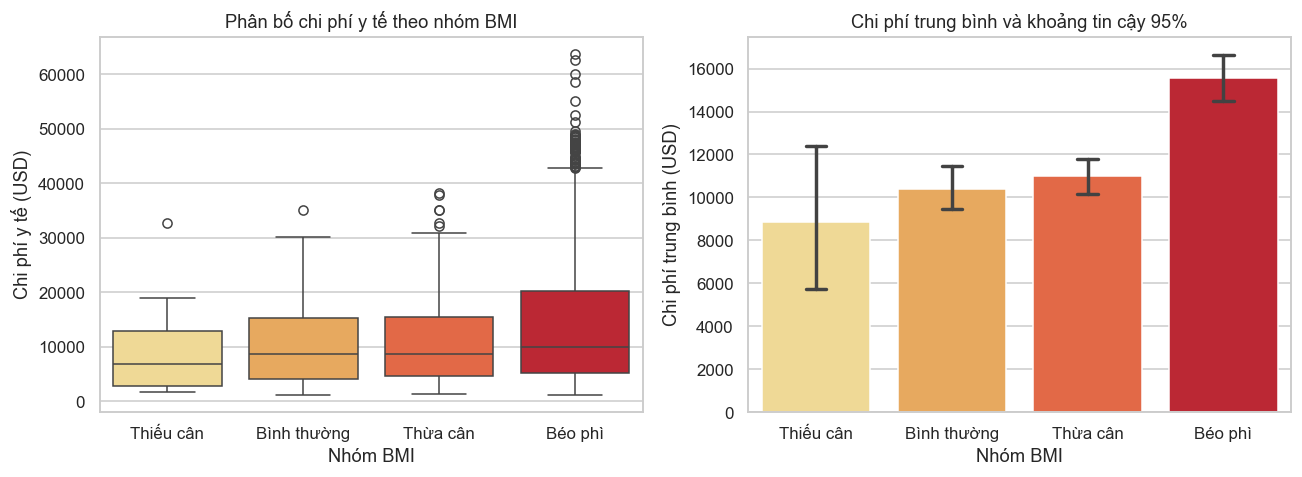

In [157]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(data=df, x="bmi_group", y="charges", palette="YlOrRd", ax=axes[0])
axes[0].set_xlabel("Nhóm BMI")
axes[0].set_ylabel("Chi phí y tế (USD)")
axes[0].set_title("Phân bố chi phí y tế theo nhóm BMI")

sns.barplot(data=df, x="bmi_group", y="charges", errorbar=("ci", 95),
            palette="YlOrRd", capsize=0.15, ax=axes[1])
axes[1].set_xlabel("Nhóm BMI")
axes[1].set_ylabel("Chi phí trung bình (USD)")
axes[1].set_title("Chi phí trung bình và khoảng tin cậy 95%")

plt.tight_layout()
plt.show()

### Bước 2. Kiểm tra điều kiện áp dụng

In [158]:
groups = [g["charges"].values for _, g in df.groupby("bmi_group", observed=True)]
group_names = labels

print("Kiểm tra phân phối chuẩn (Shapiro-Wilk) theo từng nhóm:")
for name, g in zip(group_names, groups):
    w, p = stats.shapiro(g)
    print(f"  - {name:<12}: n = {len(g):>4}, p = {p:.2e}")

lev_stat, lev_p = stats.levene(*groups)
print(f"\nKiểm tra phương sai đồng nhất (Levene): thống kê = {lev_stat:.2f}, p = {lev_p:.2e}")

Kiểm tra phân phối chuẩn (Shapiro-Wilk) theo từng nhóm:
  - Thiếu cân   : n =   20, p = 2.84e-03
  - Bình thường : n =  225, p = 7.19e-10
  - Thừa cân    : n =  386, p = 2.01e-15
  - Béo phì     : n =  706, p = 2.60e-28

Kiểm tra phương sai đồng nhất (Levene): thống kê = 22.29, p = 4.41e-14


**Nhận xét điều kiện:**

- **Phân phối không chuẩn** ở cả 4 nhóm (dữ liệu chi phí lệch phải).
- **Phương sai không đồng nhất** (Levene p rất nhỏ): điều kiện của ANOVA cổ điển bị vi phạm. Vì vậy ngoài ANOVA, ta chạy thêm **Welch's ANOVA** (không cần phương sai bằng nhau) và **Kruskal–Wallis** (phi tham số) để đối chiếu.
- Nhóm *Thiếu cân* chỉ có **20 quan sát**, nên các kết luận liên quan đến nhóm này có độ tin cậy thấp hơn.

### Bước 3. Chạy kiểm định

In [159]:
# --- (1) One-way ANOVA cổ điển ---
f_stat, p_anova = stats.f_oneway(*groups)

# --- (2) Welch's ANOVA ---
k = len(groups)
n_i = np.array([len(g) for g in groups])
m_i = np.array([g.mean() for g in groups])
v_i = np.array([g.var(ddof=1) for g in groups])
w_i = n_i / v_i
W = w_i.sum()
m_w = (w_i * m_i).sum() / W
lam = ((1 - w_i / W) ** 2 / (n_i - 1)).sum()
f_welch = ((w_i * (m_i - m_w) ** 2).sum() / (k - 1)) / (1 + 2 * (k - 2) / (k ** 2 - 1) * lam)
df2_welch = (k ** 2 - 1) / (3 * lam)
p_welch = stats.f.sf(f_welch, k - 1, df2_welch)

# --- (3) Kruskal-Wallis (phi tham số) ---
h_stat, p_kw = stats.kruskal(*groups)

# --- Độ lớn hiệu ứng: eta bình phương ---
grand_mean = df["charges"].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
ss_total   = ((df["charges"] - grand_mean) ** 2).sum()
eta_sq = ss_between / ss_total

print("KẾT QUẢ SO SÁNH CHI PHÍ Y TẾ GIỮA 4 NHÓM BMI")
print("-" * 62)
print(f"One-way ANOVA   : F = {f_stat:6.2f}, df = ({k-1}, {len(df)-k}), p = {p_anova:.2e}")
print(f"Welch's ANOVA   : F = {f_welch:6.2f}, df = ({k-1}, {df2_welch:.1f}), p = {p_welch:.2e}")
print(f"Kruskal-Wallis  : H = {h_stat:6.2f}, df = {k-1}, p = {p_kw:.2e}")
print(f"Eta bình phương = {eta_sq:.3f}  (BMI giải thích khoảng {eta_sq*100:.1f}% biến thiên của chi phí)")
print("-" * 62)
if p_anova < ALPHA:
    print(f"=> p < {ALPHA}: BÁC BỎ H0. Có ít nhất một nhóm BMI có chi phí trung bình khác biệt.")
else:
    print(f"=> p >= {ALPHA}: KHÔNG BÁC BỎ H0.")

KẾT QUẢ SO SÁNH CHI PHÍ Y TẾ GIỮA 4 NHÓM BMI
--------------------------------------------------------------
One-way ANOVA   : F =  18.87, df = (3, 1333), p = 5.44e-12
Welch's ANOVA   : F =  20.34, df = (3, 92.7), p = 3.27e-10
Kruskal-Wallis  : H =  17.05, df = 3, p = 6.91e-04
Eta bình phương = 0.041  (BMI giải thích khoảng 4.1% biến thiên của chi phí)
--------------------------------------------------------------
=> p < 0.05: BÁC BỎ H0. Có ít nhất một nhóm BMI có chi phí trung bình khác biệt.


### Bước 4. Kiểm định hậu nghiệm Tukey HSD

ANOVA mới chỉ cho biết *có khác biệt*. Tukey HSD sẽ chỉ rõ **cặp nhóm nào** khác nhau.

In [160]:
tukey = stats.tukey_hsd(*groups)
ci = tukey.confidence_interval(confidence_level=1 - ALPHA)

rows = []
for i in range(k):
    for j in range(i + 1, k):
        rows.append({
            "Cặp so sánh": f"{group_names[j]} - {group_names[i]}",
            "Chênh lệch TB (USD)": -tukey.statistic[i, j],
            "CI 95% dưới": -ci.high[i, j],
            "CI 95% trên": -ci.low[i, j],
            "P-value": tukey.pvalue[i, j],
            "Khác biệt?": "Có" if tukey.pvalue[i, j] < ALPHA else "Không",
        })

tukey_table = pd.DataFrame(rows)
tukey_table["P-value"] = tukey_table["P-value"].map(lambda p: "< 0.001" if p < 0.001 else f"{p:.3f}")
tukey_table

,Cặp so sánh,Chênh lệch TB (USD),CI 95% dưới,CI 95% trên,P-value,Khác biệt?
0,Bình thường - Thiếu cân,"1,557.14","-5,569.85","8,684.13",0.943,Không
1,Thừa cân - Thiếu cân,"2,135.31","-4,869.30","9,139.91",0.862,Không
2,Béo phì - Thiếu cân,"6,719.84",-206.12,"13,645.81",0.061,Không
3,Thừa cân - Bình thường,578.17,"-1,983.74","3,140.09",0.938,Không
4,Béo phì - Bình thường,"5,162.70","2,824.35","7,501.06",< 0.001,Có
5,Béo phì - Thừa cân,"4,584.53","2,651.03","6,518.03",< 0.001,Có


### Bước 5. Kiểm tra bổ sung: kết quả có còn đúng khi loại bỏ yếu tố hút thuốc?

Ở Câu hỏi 1 ta thấy hút thuốc ảnh hưởng rất mạnh đến chi phí. Cần chắc rằng sự khác biệt giữa các nhóm BMI **không chỉ do** tỷ lệ người hút thuốc khác nhau giữa các nhóm. Ta lặp lại phép kiểm định **chỉ trên nhóm không hút thuốc**.

In [161]:
# Tỷ lệ người hút thuốc trong từng nhóm BMI
print("Tỷ lệ người hút thuốc theo nhóm BMI:")
display((pd.crosstab(df["bmi_group"], df["smoker"], normalize="index")["yes"] * 100)
        .round(1).rename("% hút thuốc").to_frame())

# Lặp lại kiểm định chỉ với người không hút thuốc
ns = df[df["smoker"] == "no"]
groups_ns = [g["charges"].values for _, g in ns.groupby("bmi_group", observed=True)]
f_ns, p_ns = stats.f_oneway(*groups_ns)
h_ns, p_kw_ns = stats.kruskal(*groups_ns)

print(f"\nChỉ nhóm không hút thuốc (n = {len(ns):,}):")
print(f"  One-way ANOVA : F = {f_ns:.2f}, p = {p_ns:.4f}")
print(f"  Kruskal-Wallis: H = {h_ns:.2f}, p = {p_kw_ns:.4f}")

Tỷ lệ người hút thuốc theo nhóm BMI:


,% hút thuốc
bmi_group,
Thiếu cân,25.00
Bình thường,22.20
Thừa cân,19.20
Béo phì,20.50



Chỉ nhóm không hút thuốc (n = 1,063):
  One-way ANOVA : F = 3.11, p = 0.0255
  Kruskal-Wallis: H = 12.93, p = 0.0048


### Bước 6. Giải thích kết quả

- **Giải thích P-value:** cả ba phép kiểm định đều cho p rất nhỏ (ANOVA: p ≈ 5,4 × 10⁻¹²; Welch: p ≈ 3,3 × 10⁻¹⁰; Kruskal–Wallis: p ≈ 0,0007), đều nhỏ hơn α = 0,05. Nếu chi phí y tế trung bình thật sự bằng nhau giữa 4 nhóm BMI thì xác suất thấy được khác biệt như trong mẫu là cực kỳ nhỏ, nên ta **bác bỏ H0**. Việc ba phương pháp (trong đó có hai phương pháp không đòi hỏi phương sai đồng nhất) cùng đi đến một kết luận cho thấy kết quả **vững**.
- **Nhóm nào khác nhóm nào (Tukey HSD):** sự khác biệt có ý nghĩa thống kê **chỉ xuất hiện ở nhóm Béo phì**: chi phí trung bình của nhóm Béo phì (khoảng **15.572 USD**) cao hơn nhóm Bình thường (10.409 USD) khoảng 5.200 USD và cao hơn nhóm Thừa cân (10.988 USD) khoảng 4.600 USD. Các cặp còn lại (Thiếu cân, Bình thường, Thừa cân so với nhau) **không** khác biệt có ý nghĩa. Cặp Béo phì với Thiếu cân có p ≈ 0,06, chưa đạt ngưỡng 0,05, nhưng cần lưu ý nhóm Thiếu cân chỉ có 20 quan sát nên thiếu sức mạnh thống kê.
- **Độ lớn hiệu ứng:** η² ≈ 0,04 nghĩa là nhóm BMI chỉ giải thích khoảng **4%** biến thiên của chi phí, tức hiệu ứng **nhỏ đến trung bình**. Đây là điểm quan trọng: khác biệt có thật (p nhỏ) nhưng **không lớn** như yếu tố hút thuốc.
- **Kiểm tra bổ sung:** tỷ lệ hút thuốc giữa các nhóm BMI khá tương đồng (khoảng 19% đến 25%), và khi chỉ xét người không hút thuốc, khác biệt giữa các nhóm BMI **vẫn có ý nghĩa** (ANOVA p ≈ 0,025; Kruskal–Wallis p ≈ 0,005). Vậy ảnh hưởng của BMI không chỉ là hệ quả của việc hút thuốc.

**Kết luận câu hỏi 2:** Chi phí y tế có khác nhau giữa các nhóm BMI, và khác biệt chủ yếu đến từ nhóm **Béo phì** có chi phí cao hơn các nhóm còn lại. Tuy nhiên, mức độ ảnh hưởng của BMI nhỏ hơn nhiều so với hút thuốc.

---
# PHẦN E. TỔNG KẾT
### Tổng hợp kết quả
| # | Câu hỏi nghiên cứu | Phép kiểm định | P-value | Độ lớn hiệu ứng | Kết luận |
|---|---|---|---|---|---|
| 1 | Chi phí y tế của người hút thuốc có khác người không hút thuốc? | Welch's t-test | ≈ 6,3 × 10⁻¹⁰³ | Cohen's d ≈ 3,16 (rất lớn) | Có khác biệt; người hút thuốc chi phí cao gấp ~3,8 lần |
| 2 | Chi phí y tế có khác nhau giữa các nhóm BMI? | ANOVA + Tukey HSD | ≈ 5,4 × 10⁻¹² | η² ≈ 0,04 (nhỏ) | Có khác biệt; chủ yếu do nhóm Béo phì cao hơn |
### Liên hệ
- **Mục tiêu 1 (hút thuốc và chi phí):** hút thuốc là yếu tố có ảnh hưởng **mạnh nhất**, đây là biến cần được ưu tiên đưa vào mô hình dự đoán.
- **Mục tiêu 2 (BMI và chi phí):** BMI có ảnh hưởng thật nhưng ở mức vừa phải, tập trung ở nhóm béo phì. Gợi ý cho phần mô hình: có thể tạo biến cờ "béo phì" (BMI ≥ 30) hoặc xét **tương tác giữa BMI và hút thuốc**.


---
---
# PHẦN 4 & 5: PHÂN TÍCH TƯƠNG QUAN & HỒI QUY ĐA BIẾN
---


# PHẦN 4 & 5: PHÂN TÍCH TƯƠNG QUAN VÀ HỒI QUY TUYẾN TÍNH ĐA BIẾN

## 1. Chuẩn bị Dữ liệu
Nhóm sẽ nạp tập dữ liệu đã được làm sạch (`clean_data.csv`). Mục tiêu là xây dựng mô hình học máy để dự đoán chi phí y tế (`charges`) dựa trên các đặc trưng cá nhân.


In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Đọc dữ liệu đã được làm sạch từ bước EDA
df = pd.read_csv('data/clean_data.csv')

# Hiển thị 5 dòng đầu tiên để kiểm tra
display(df.head())


,age,sex,bmi,children,smoker,region,charges,log_charges
0,19,female,27.90,0,yes,southwest,"16,884.92",9.73
1,18,male,33.77,1,no,southeast,"1,725.55",7.45
2,28,male,33.00,3,no,southeast,"4,449.46",8.40
3,33,male,22.70,0,no,northwest,"21,984.47",10.00
4,32,male,28.88,0,no,northwest,"3,866.86",8.26


## 2. Tiền xử lý dữ liệu cho Hồi quy (One-Hot Encoding)
Mô hình Hồi quy tuyến tính (Linear Regression) chỉ có thể tính toán trên dữ liệu dạng số. Do đó, cần chuyển các biến phân loại (Categorical) như `sex`, `smoker`, và `region` thành dạng số bằng phương pháp **One-Hot Encoding**.

*Lưu ý:* Để tránh hiện tượng **Đa cộng tuyến hoàn hảo (Dummy Variable Trap)** - nơi các biến dự đoán hoàn hảo cho nhau gây nhiễu mô hình, nhóm sử dụng tham số `drop_first=True` để loại bỏ đi cột đầu tiên của mỗi nhóm.


In [163]:
# Loại bỏ cột log_charges. (Giải thích: Phần 5 dùng charges gốc để RMSE/MAE tính theo đơn vị USD, dễ diễn giải; log_charges đã được dùng ở Phần 2 cho phân phối).
if 'log_charges' in df.columns:
    df = df.drop(columns=['log_charges'])
# Mã hóa các biến phân loại và loại bỏ cột đầu tiên (drop_first=True) để tránh bẫy biến giả
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
# Ép kiểu dữ liệu từ boolean (True/False) về số thực (1.0 / 0.0)
df_encoded = df_encoded.astype(float)
# Kiểm tra dữ liệu sau khi biến đổi
print("Dữ liệu sau khi mã hóa One-Hot Encoding:")
display(df_encoded.head())


Dữ liệu sau khi mã hóa One-Hot Encoding:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19.00,27.90,0.00,"16,884.92",0.00,1.00,0.00,0.00,1.00
1,18.00,33.77,1.00,"1,725.55",1.00,0.00,0.00,1.00,0.00
2,28.00,33.00,3.00,"4,449.46",1.00,0.00,0.00,1.00,0.00
3,33.00,22.70,0.00,"21,984.47",1.00,0.00,1.00,0.00,0.00
4,32.00,28.88,0.00,"3,866.86",1.00,0.00,1.00,0.00,0.00


## 3. Phân tích Tương quan (Correlation Analysis)
### 3.1. Cơ sở lý thuyết

**a. Hệ số tương quan Pearson ($r$)**
- **Khái niệm:** Đo lường mức độ tương quan *tuyến tính* (đường thẳng) giữa hai biến định lượng.
- **Công thức:** 
  $$r = \frac{\sum(X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum(X_i-\bar{X})^2 \cdot \sum(Y_i-\bar{Y})^2}}$$
- **Điều kiện áp dụng:** Các biến số phải là biến định lượng (liên tục) và có phân phối tương đối chuẩn. Không có các giá trị ngoại lai quá cực đoan.
- **Ví dụ minh họa:** Tương quan giữa *Số giờ ôn tập* và *Điểm thi*. Học càng nhiều giờ, điểm số càng tăng ổn định theo một đường thẳng, thì Pearson sẽ tiến gần về 1.

**b. Hệ số tương quan Spearman ($\rho$)**
- **Khái niệm:** Đo lường dựa trên *thứ hạng* của dữ liệu (Rank-order) thay vì giá trị thực tế. Phù hợp cho mối quan hệ đơn điệu (Monotonic).
- **Công thức:**
  $$\rho = 1 - \frac{6\sum d_i^2}{n(n^2-1)}$$
  *(Trong đó $d_i$ là hiệu số thứ hạng giữa hai biến, $n$ là số quan sát)*
- **Điều kiện áp dụng:** Dùng khi dữ liệu không có phân phối chuẩn, có ngoại lai, hoặc khi đo lường tương quan cho các biến thứ bậc (Ordinal).
- **Ví dụ minh họa:** Tương quan giữa *Thứ hạng trong lớp* và *Mức độ hài lòng*. Đây là những biến có tính thứ bậc nên dùng Spearman là chính xác nhất.

**c. Thang đánh giá cường độ tương quan (Giá trị tuyệt đối $|r|$ hoặc $|\rho|$)**
- $0.00 \leq |r| < 0.30$: Tương quan rất yếu (hoặc không tương quan).
- $0.30 \leq |r| < 0.50$: Tương quan yếu / trung bình.
- $0.50 \leq |r| < 0.70$: Tương quan khá mạnh.
- $0.70 \leq |r| \leq 1.00$: Tương quan rất mạnh.

> **Lưu ý về các biến nhị phân (`smoker`, `sex`)**: 
> Khi tính Pearson cho một biến liên tục và một biến nhị phân (chỉ có 0 và 1), hệ số này thực chất tương đương với Điểm tương quan Biserial (Point-Biserial Correlation). Nó phản ánh sự khác biệt về trung bình (mean) của biến liên tục giữa 2 nhóm của biến nhị phân đó.

---
### 3.2. Áp dụng vào bộ dữ liệu
Trước khi đưa dữ liệu vào huấn luyện, cần đánh giá xem đặc trưng nào có ảnh hưởng mạnh nhất đến `charges` (Chi phí). 



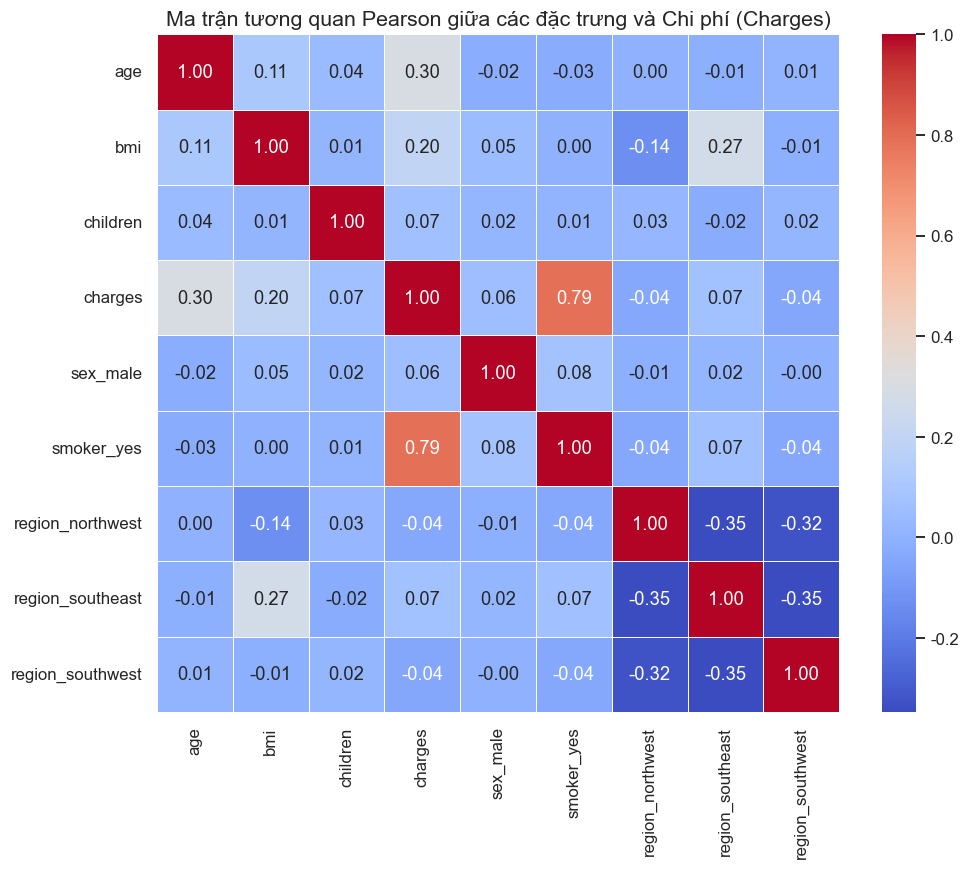


Mức độ tương quan của các biến đối với chi phí y tế (Charges):
charges             1.00
smoker_yes          0.79
age                 0.30
bmi                 0.20
region_southeast    0.07
children            0.07
sex_male            0.06
region_northwest   -0.04
region_southwest   -0.04
Name: charges, dtype: float64


In [164]:
# Cài đặt kích thước biểu đồ
plt.figure(figsize=(10, 8))

# Tính toán ma trận tương quan Pearson
correlation_matrix = df_encoded.corr()

# Vẽ bản đồ nhiệt (Heatmap)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan Pearson giữa các đặc trưng và Chi phí (Charges)', fontsize=14)
plt.savefig('charts/4_heatmap_pearson.png', bbox_inches='tight', dpi=300)
plt.show()

# In ra danh sách các biến có tương quan mạnh nhất với 'charges'
print("\nMức độ tương quan của các biến đối với chi phí y tế (Charges):")
print(correlation_matrix['charges'].sort_values(ascending=False))


### Đánh giá thêm bằng Tương quan Spearman
Ngoài tương quan Pearson (chỉ đánh giá mối quan hệ tuyến tính/đường thẳng), nhóm tiến hành đo lường thêm bằng **Tương quan Spearman** (đánh giá dựa trên thứ hạng). 

Việc bổ sung thước đo Spearman giúp khẳng định chắc chắn hơn về mối quan hệ "đơn điệu" giữa các biến (ví dụ: tuổi cứ tăng thì chi phí cứ tăng). Đặc biệt, Spearman ít bị ảnh hưởng với các giá trị ngoại lai (những khách hàng có chi phí y tế cao bất thường), giúp kết quả phân tích đáng tin cậy hơn.


In [165]:
correlation_matrix_spearman = df_encoded.corr(method='spearman')
print("Mức độ tương quan SPEARMAN của các biến đối với chi phí y tế (Charges):")
print(correlation_matrix_spearman['charges'].sort_values(ascending=False))

Mức độ tương quan SPEARMAN của các biến đối với chi phí y tế (Charges):
charges             1.00
smoker_yes          0.66
age                 0.53
children            0.13
bmi                 0.12
region_southeast    0.02
sex_male            0.01
region_northwest   -0.02
region_southwest   -0.04
Name: charges, dtype: float64


### Trực quan hóa tương quan bằng Scatter Plot
Để làm rõ hơn mối quan hệ giữa các biến, ta sử dụng biểu đồ phân tán (Scatter Plot) giữa hai biến có tương quan mạnh nhất với `charges` là `age` và `smoker_yes`. Mỗi điểm được tô màu theo tình trạng hút thuốc để làm nổi bật sự khác biệt giữa hai nhóm.

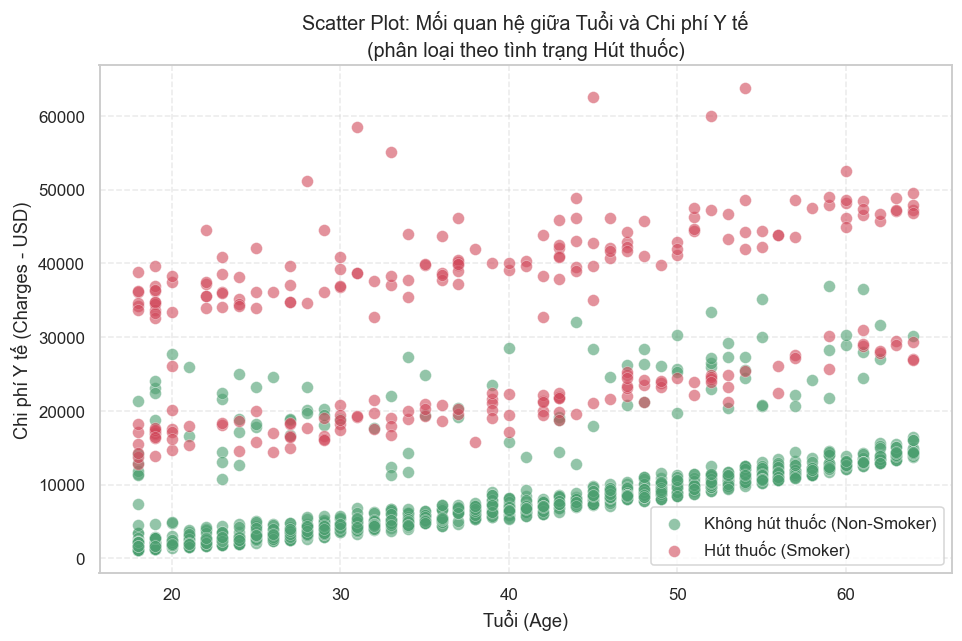

In [166]:
import os
# Đọc lại dữ liệu gốc (chưa mã hóa) để có cột 'smoker' dạng text cho việc tô màu
df_plot = pd.read_csv('data/clean_data.csv')
# Vẽ Scatter Plot: age vs charges, tô màu theo smoker
plt.figure(figsize=(10, 6))
colors = {'yes': '#D1495B', 'no': '#4C9F70'}
labels = {'yes': 'Hút thuốc (Smoker)', 'no': 'Không hút thuốc (Non-Smoker)'}
for status in ['no', 'yes']:
    subset = df_plot[df_plot['smoker'] == status]
    plt.scatter(
        subset['age'], subset['charges'],
        c=colors[status], label=labels[status],
        alpha=0.6, edgecolors='white', linewidths=0.3, s=60
    )
plt.xlabel('Tuổi (Age)', fontsize=12)
plt.ylabel('Chi phí Y tế (Charges - USD)', fontsize=12)
plt.title('Scatter Plot: Mối quan hệ giữa Tuổi và Chi phí Y tế\n(phân loại theo tình trạng Hút thuốc)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig('charts/5_scatter_age_charges_smoker.png', bbox_inches='tight', dpi=300)
plt.show()


### Nhận xét chung về Tương quan & Ý nghĩa thực tiễn:
1. **Khác biệt Pearson vs Spearman**: 
   - Biến `age` có Pearson là 0.30 nhưng Spearman là 0.53. Điều này cho thấy tuổi tác có xu hướng tăng đơn điệu với chi phí, nhưng không hoàn toàn tuyến tính do bị nhiễu.
   - `smoker_yes` có Pearson rất cao (0.79). Vì đây là biến nhị phân, con số này phản ánh sự chênh lệch rất lớn về trung bình viện phí giữa nhóm hút thuốc và không hút thuốc (như lưu ý Point-Biserial ở phần lý thuyết).
   - `bmi` và `children` có tương quan dương nhưng rất yếu (quanh mức 0.1 - 0.2).
2. **Scatter Plot (Tuổi vs Chi phí theo tình trạng hút thuốc)**:
   - **Nhóm HÚT THUỐC (đỏ)**: Nằm ở dải chi phí phần lớn cao hơn (có một vùng chồng lấn nhỏ) so với phần còn lại.
   - **Nhóm KHÔNG HÚT THUỐC (xanh)**: Nằm ở dải chi phí thấp dưới đáy đồ thị.
   - Cả hai nhóm đều có xu hướng tịnh tiến lên trên khi tuổi tác tăng lên. Đồ thị này minh họa rõ nét tác động của tình trạng hút thuốc.
3. **Ý nghĩa thực tiễn**:
   - Tuổi tác và thói quen hút thuốc là hai yếu tố đẩy rủi ro y tế lên cao nhất. Trong thực tế, các công ty bảo hiểm đặc biệt khắt khe và thường áp mức phí cao hơn rất nhiều đối với khách hàng có hút thuốc hoặc khách hàng lớn tuổi.
   - Dù `bmi` có tương quan tổng thể yếu, nhưng kết hợp với việc hút thuốc có thể dẫn đến chi phí khổng lồ (bệnh lý tim mạch, hô hấp...).


## 4. Lựa chọn đặc trưng và Phân chia tập dữ liệu (Train/Test Split)
### 4.1. Lựa chọn đặc trưng (Feature Selection)
Dựa vào kết quả phân tích Ma trận tương quan (Heatmap Pearson) và Tương quan Spearman ở trên, ta thấy:
*   Biến `smoker_yes` và `age` có tương quan rõ rệt. Biến `bmi` có tương quan yếu (0.20) nhưng được giữ lại vì có cơ sở y khoa rõ ràng đối với chi phí y tế (`charges`).
*   Các biến giới tính (`sex`) và vùng miền (`region`) có hệ số tương quan rất thấp (gần như bằng 0). 
Do đó, để mô hình hoạt động hiệu quả, nhóm quyết định **loại bỏ các biến giới tính, vùng miền** do tương quan tuyến tính quá thấp. 
**Lưu ý:** Riêng đối với biến **`children` (số con)**, mặc dù tương quan tuyến tính thấp, nhưng xét về ý nghĩa thực tiễn, số con ảnh hưởng trực tiếp đến quy mô gia đình và cấu trúc gói bảo hiểm. Vì vậy, nhóm quyết định **vẫn giữ lại biến này** để đưa vào phương trình Hồi quy đa biến.
### 4.2. Phân chia dữ liệu (Train/Test)
Để đánh giá chính xác độ tin cậy của mô hình học máy, ta không được phép huấn luyện trên toàn bộ dữ liệu. Ta sẽ tách biến mục tiêu (Y) ra khỏi các biến đặc trưng (X), sau đó chia tập dữ liệu thành 2 phần:
*   **Tập huấn luyện (Train dataset - 80%):** Dùng làm sách giáo khoa để dạy cho thuật toán tìm ra quy luật.
*   **Tập kiểm thử (Test dataset - 20%):** Dùng làm "đề thi" để kiểm tra xem mô hình dự đoán có chính xác trên những dữ liệu mà nó chưa từng thấy hay không.


In [167]:
# CHỌN BIẾN ĐƯA VÀO MÔ HÌNH: 
# Dựa vào tương quan, ta loại sex và region. Riêng biến 'children' dù tương quan thấp nhưng mang ý nghĩa thực tiễn về quy mô bảo hiểm gia đình nên vẫn giữ lại. 
features = ['age', 'bmi', 'children', 'smoker_yes']
X = df_encoded[features]
y = df_encoded['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Kích thước tập Huấn luyện (Train): {X_train.shape[0]} dòng")
print(f"Kích thước tập Kiểm thử (Test): {X_test.shape[0]} dòng")


Kích thước tập Huấn luyện (Train): 1069 dòng
Kích thước tập Kiểm thử (Test): 268 dòng


## 5. Huấn luyện mô hình Hồi quy đa biến (Multiple Linear Regression)
### 5.1. Cơ sở lý thuyết về Hồi quy đa biến
- **Khái niệm:** Là một phương pháp thống kê dùng để mô hình hóa mối quan hệ giữa **một biến phụ thuộc** (biến mục tiêu - Y) và **hai hay nhiều biến độc lập** (đặc trưng - $X_1, X_2, ...$).
- **Phương trình hồi quy:**
  $$Y = \beta_0 + \beta_1X_1 + \beta_2X_2 + ... + \beta_nX_n + \epsilon$$
  Trong đó:
  + $Y$: Biến phụ thuộc cần dự đoán.
  + $X_i$: Các biến độc lập đầu vào.
  + $\beta_0$: Hệ số tự do (Intercept) - điểm cắt với trục tung.
  + $\beta_i$: Trọng số (Coefficient) của từng biến $X_i$, thể hiện mức độ tác động của $X_i$ lên $Y$.
  + $\epsilon$: Sai số ngẫu nhiên của mô hình.
- **Ví dụ minh họa:** Dự đoán **Giá nhà (Y)** dựa vào nhiều yếu tố: **Diện tích ($X_1$)**, **Số phòng ngủ ($X_2$)**, và **Khoảng cách đến trung tâm ($X_3$)**. Mỗi yếu tố sẽ có một trọng số $\beta$ riêng quyết định mức độ ảnh hưởng của nó đến giá nhà.
---
### 5.2. Xây dựng mô hình dự đoán Chi phí Y tế
Ở bài toán này, mô hình sẽ học các trọng số $\beta$ để dự đoán `charges` dựa trên các biến độc lập như `age`, `bmi`, `children`, `smoker`...
*(Lưu ý: Khác với phần 1 gợi ý dùng log_charges, ở phần Hồi quy này nhóm sử dụng `charges` gốc làm biến mục tiêu để các chỉ số sai số như RMSE/MAE được tính theo đơn vị USD, giúp dễ diễn giải ý nghĩa thực tiễn hơn).* 


In [168]:
model = LinearRegression()

# Bắt đầu huấn luyện mô hình (Học từ dữ liệu Train)
model.fit(X_train, y_train)

# In ra các hệ số (Coefficients) mà mô hình học được
coefficients = pd.DataFrame({
    'Đặc trưng (Feature)': X.columns,
    'Trọng số (Coefficient)': model.coef_
}).sort_values(by='Trọng số (Coefficient)', ascending=False)

print(f"Hệ số cơ bản (Intercept - a): {model.intercept_:,.2f}")
print("\nTrọng số của từng đặc trưng:")
display(coefficients)


Hệ số cơ bản (Intercept - a): -11,256.75

Trọng số của từng đặc trưng:


,Đặc trưng (Feature),Trọng số (Coefficient)
3,smoker_yes,"23,042.51"
2,children,537.97
1,bmi,305.27
0,age,249.19


### Giải thích ý nghĩa các hệ số Hồi quy:
Trong mô hình Hồi quy đa biến, các hệ số (Coefficients) thể hiện mức độ tác động của từng biến độc lập lên chi phí y tế, **với điều kiện các biến khác không đổi (ceteris paribus)**:
- **`smoker_yes` (23,042.51 USD)**: Yếu tố tác động mạnh nhất. Việc hút thuốc làm tăng chi phí y tế lên khoảng **23,043 USD** so với người không hút thuốc.
- **`age` (249.19 USD)**: Mỗi tuổi tăng thêm sẽ kéo theo chi phí y tế tăng trung bình khoảng **249 USD**.
- **`bmi` (305.27 USD)**: Mỗi đơn vị BMI tăng thêm làm chi phí tăng trung bình khoảng **305 USD**.
- **`children` (537.97 USD)**: Mỗi người con tăng thêm làm chi phí y tế tăng trung bình khoảng **538 USD**.



## 6. Đánh giá sai số của mô hình (Model Evaluation)
Sau khi mô hình đã học xong, đưa tập đề thi `X_test` vào để bắt nó dự đoán kết quả (`y_pred`). Sau đó, so sánh `y_pred` với đáp án thực tế `y_test` bằng các chỉ số:
*   **R-squared ($R^2$):** Tỷ lệ % sự biến thiên của chi phí được mô hình giải thích (Càng gần 1 càng tốt).
*   **MSE (Mean Squared Error):** Trung bình bình phương sai số (Càng nhỏ càng tốt).
*   **RMSE (Root Mean Squared Error):** Căn bậc hai của MSE, cùng đơn vị với chi phí y tế nên dễ diễn giải hơn MSE.
*   **MAE (Mean Absolute Error):** Sai số tuyệt đối trung bình (Dễ hình dung hơn về mặt số tiền).


Đánh giá mô hình trên tập Kiểm thử (Test):
- Hệ số xác định (R-squared): 0.8046 (~80.46%)
- R² trên tập Huấn luyện (Train): 0.7292 (~72.92%)
- Trung bình bình phương sai số (MSE): 35,914,551.48
- Căn bậc hai sai số bình phương (RMSE): 5,992.88 USD
- Sai số tuyệt đối trung bình (MAE): 4,198.59 USD


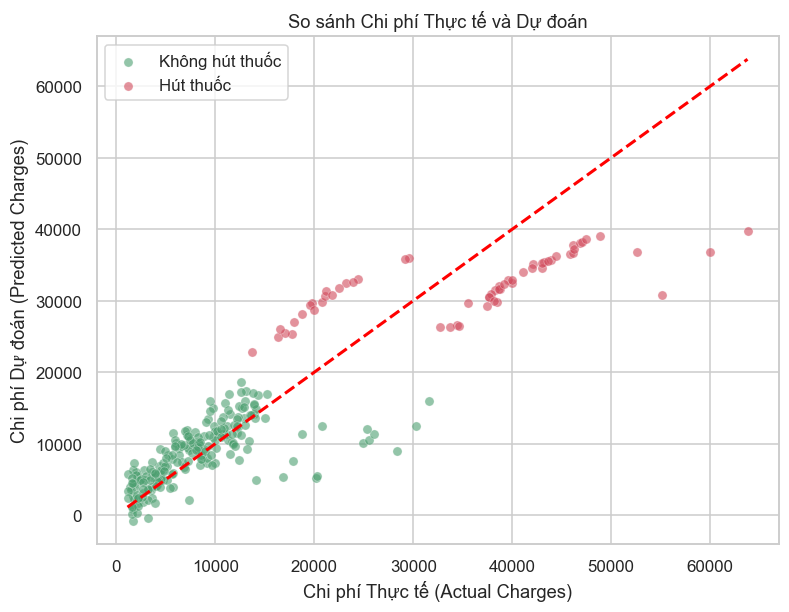

In [169]:
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)
# Tính các chỉ số đánh giá trên tập TEST
r2       = r2_score(y_test, y_pred)
mse      = mean_squared_error(y_test, y_pred)
rmse     = mse ** 0.5
mae      = mean_absolute_error(y_test, y_pred)
# Tính R² trên tập TRAIN để so sánh (phát hiện overfitting)
r2_train = r2_score(y_train, y_pred_train)
print(f"Đánh giá mô hình trên tập Kiểm thử (Test):")
print(f"- Hệ số xác định (R-squared): {r2:.4f} (~{r2*100:.2f}%)")
print(f"- R² trên tập Huấn luyện (Train): {r2_train:.4f} (~{r2_train*100:.2f}%)")
print(f"- Trung bình bình phương sai số (MSE): {mse:,.2f}")
print(f"- Căn bậc hai sai số bình phương (RMSE): {rmse:,.2f} USD")
print(f"- Sai số tuyệt đối trung bình (MAE): {mae:,.2f} USD")
plt.figure(figsize=(8,6))
for val, name, col in [(0, 'Không hút thuốc', '#4C9F70'), (1, 'Hút thuốc', '#D1495B')]:
    m = X_test['smoker_yes'] == val
    plt.scatter(y_test[m], y_pred[m], alpha=0.6, color=col, edgecolors='white', linewidths=0.3, label=name)
plt.legend()
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.xlabel('Chi phí Thực tế (Actual Charges)')
plt.ylabel('Chi phí Dự đoán (Predicted Charges)')
plt.title('So sánh Chi phí Thực tế và Dự đoán')
plt.savefig('charts/6_actual_vs_predicted.png', bbox_inches='tight', dpi=300)
plt.show()


### Nhận xét kết quả Hồi quy:
1. **Đánh giá R² và Overfitting**:
   - R² train (0.73) và test (0.80) không chênh lệch lớn và điểm train không cao hơn test, do đó không có dấu hiệu overfitting. Mô hình giải thích được khoảng 80% phương sai trên tập kiểm thử.
2. **Sai số (RMSE & MAE)**:
   - MAE ~4,198 USD và RMSE ~5,993 USD cho thấy trung bình mỗi dự đoán lệch khoảng 4-6 nghìn đô. Mức sai số này tuy khá lớn (chiếm khoảng 45% so với trung bình 13,279 USD) nhưng vẫn chấp nhận được đối với mô hình tuyến tính cơ sở do bản chất dữ liệu y tế dao động rất cực đoan.
3. **Biểu đồ Thực tế vs Dự đoán**:
   - Phần lớn các điểm phân bổ bám theo đường chéo màu đỏ ($y=x$), nhưng **tồn tại lỗi hệ thống** do mô hình chưa nắm bắt hết tương tác phức tạp.
   - **Nhóm Không hút thuốc (màu xanh)**: Đa phần dự đoán khá tốt, nhưng có một cụm chi phí thực tế cao (17,000 - 30,000 USD) lại bị mô hình dự đoán rất thấp (chỉ khoảng 5,000 - 12,000 USD).
   - **Nhóm Hút thuốc (màu đỏ)**: Bị tách thành 2 dải song song (một dải nằm trên đường $y=x$, một dải nằm dưới). Sự phân tách này có thể do **tác động tương tác kép giữa Béo phì và Hút thuốc** (Bởi vì dữ liệu thực tế cho thấy: người hút thuốc có BMI $\geq 30$ tốn trung bình tới ~41,558 USD, trong khi người hút thuốc BMI $< 30$ chỉ tốn ~21,363 USD).



### Ví dụ minh họa dự đoán thực tế
Để kiểm chứng mô hình, ta thử dự đoán chi phí y tế cho một hồ sơ cụ thể.

In [170]:
# Ví dụ: Dự đoán chi phí y tế cho một người cụ thể
# Hồ sơ: 40 tuổi, BMI = 30, 2 con, hút thuốc
age_val      = 40
bmi_val      = 30
children_val = 2
smoker_val   = 1  # 1 = hút thuốc
# Đưa vào mô hình dự đoán
sample = pd.DataFrame([[age_val, bmi_val, children_val, smoker_val]], columns=['age', 'bmi', 'children', 'smoker_yes'])
predicted_cost = model.predict(sample)[0]
print("=" * 50)
print("VÍ DỤ DỰ ĐOÁN CHI PHÍ Y TẾ")
print("=" * 50)
print(f"Thông tin hồ sơ:")
print(f"  - Tuổi         : {age_val}")
print(f"  - BMI          : {bmi_val}")
print(f"  - Số con       : {children_val}")
print(f"  - Hút thuốc    : {'Có' if smoker_val == 1 else 'Không'}")
print(f"")
print(f"Chi phí y tế dự đoán: {predicted_cost:,.2f} USD")
print("=" * 50)
print(f"Kiểm tra thủ công:")
print(f"  ({model.intercept_:.2f}) + {model.coef_[0]:.2f}×{age_val} + {model.coef_[1]:.2f}×{bmi_val} + {model.coef_[2]:.2f}×{children_val} + {model.coef_[3]:.2f}×{smoker_val}")
manual = model.intercept_ + model.coef_[0]*age_val + model.coef_[1]*bmi_val + model.coef_[2]*children_val + model.coef_[3]*smoker_val
print(f"  = {manual:,.2f} USD")


VÍ DỤ DỰ ĐOÁN CHI PHÍ Y TẾ
Thông tin hồ sơ:
  - Tuổi         : 40
  - BMI          : 30
  - Số con       : 2
  - Hút thuốc    : Có

Chi phí y tế dự đoán: 31,987.38 USD
Kiểm tra thủ công:
  (-11256.75) + 249.19×40 + 305.27×30 + 537.97×2 + 23042.51×1
  = 31,987.38 USD
